## **Important Libraries**

This project uses several Python libraries for data processing, visualization, technical indicator calculation, feature engineering, feature selection, time-series validation, machine learning, and model evaluation.

- **Pandas** and **NumPy** are used for data manipulation and numerical operations.
- **Matplotlib** and **Seaborn** are used for data visualization.
- **TA (Technical Analysis)** indicators are used to generate financial features such as RSI, MACD, Bollinger Bands, ATR, and ROC.
- **Scikit-learn** provides machine learning algorithms, time-series cross-validation, and evaluation metrics.
- **BorutaPy** is used for selecting important features.
- **XGBoost** and **CatBoost** are used as advanced boosting-based machine learning models.

The overall workflow is:

**Data → EDA → Visualization → Feature Engineering → Target Creation → Time-Series Split → Feature Selection → Preprocessing → Model Training → Evaluation**

In [121]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np
from ta.momentum import RSIIndicator, ROCIndicator
from ta.trend import MACD
from ta.volatility import BollingerBands, AverageTrueRange
from pandas.plotting import autocorrelation_plot
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from boruta import BorutaPy
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import    accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,Flatten
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings("ignore")

# ****Dataset Load****

The dataset contains historical stock market information from the Dhaka Stock Exchange (DSE).

The dataset includes:

- Date
- Scrip
- Open
- High
- Low
- Close
- Volume

The `Date` column is converted into datetime format, and the data is initially sorted by stock (`Scrip`) and date so that all time-dependent calculations are performed in the correct chronological order.

Since this is a financial time-series dataset, maintaining the chronological order of observations is essential.

In [2]:
df = pd.read_csv("merged_data.csv")

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values(["Scrip", "Date"]).reset_index(drop=True)

# Initial Dataset Inspection

The first few observations are displayed to understand the structure and format of the dataset.

This helps us verify that the stock identifiers, dates, OHLC prices, and trading volume have been loaded correctly.

# See  dataset first 5 rows

In [3]:
# See the first 5 rows
df.head().T

,0,1,2,3,4
Date,2013-01-28 00:00:00,2013-01-29 00:00:00,2013-01-30 00:00:00,2013-01-31 00:00:00,2013-02-03 00:00:00
Scrip,00DS30,00DS30,00DS30,00DS30,00DS30
Open,1460.3,1473.01,1495.67,1486.56,1488.56
High,1476.26,1500.77,1506.46,1495.53,1499.44
Low,1459.67,1473.01,1485.94,1483.61,1481.38
Close,1473.01,1495.67,1486.56,1488.56,1494.15
Volume,833692000,1326800000,1054900000,925494000,1081130000


# See  dataset last 5 rows

In [4]:
# See the Last 5 rows
df.tail().T

,1381566,1381567,1381568,1381569,1381570
Date,2025-02-20 00:00:00,2025-02-23 00:00:00,2025-02-24 00:00:00,2025-02-25 00:00:00,2025-02-26 00:00:00
Scrip,ZEALBANGLA,ZEALBANGLA,ZEALBANGLA,ZEALBANGLA,ZEALBANGLA
Open,85.1,84.4,84.8,84.9,85.9
High,86.1,85.0,84.9,85.0,85.9
Low,83.0,82.0,83.6,83.1,83.3
Close,84.8,82.5,84.0,84.6,84.4
Volume,3302,6401,1617,1826,1112


# Final Dataset Inspection

The last few observations are inspected to understand the latest available records in the dataset.

This also helps verify the overall date coverage of the dataset.

# Dataset Dimensions

In [5]:
# Datast shape
df.shape

(1381571, 7)

# Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1381571 entries, 0 to 1381570
Data columns (total 7 columns):
 #   Column  Non-Null Count    Dtype         
---  ------  --------------    -----         
 0   Date    1381571 non-null  datetime64[ns]
 1   Scrip   1381571 non-null  object        
 2   Open    1381571 non-null  float64       
 3   High    1381571 non-null  float64       
 4   Low     1381571 non-null  float64       
 5   Close   1381571 non-null  float64       
 6   Volume  1381571 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 73.8+ MB


# Dataset Information

The dataset information is examined to identify:

- Number of observations
- Number of columns
- Data types
- Missing values
- Memory usage

This step is important because different variables require different types of preprocessing.

# Statistical Summary

In [7]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,1381571,2016-04-05 09:50:03.168132352,2000-01-01 00:00:00,2011-12-22 00:00:00,2017-01-25 00:00:00,2021-05-31 00:00:00,2025-02-26 00:00:00,NaN
Open,1381571.0,105.470411,-0.274725,12.480926,26.296,61.157025,1037500.0,966.494647
High,1381571.0,106.811992,0.0,12.7,26.740646,62.278239,1037500.0,967.804527
Low,1381571.0,104.0851,-0.3663,12.2449,25.75,60.0,1037500.0,965.369466
Close,1381571.0,105.22715,0.004381,12.426304,26.162435,60.952713,1037500.0,966.39914
Volume,1381571.0,48298221.70188,0.0,20637.0,123500.0,497629.5,56079084403.0,690917006.34529


# Statistical Summary

Descriptive statistics are generated for the numerical variables.

This provides information about:

- Mean
- Minimum and maximum values
- Standard deviation
- Quartiles

The summary helps identify the scale and distribution of the financial variables and can also reveal potential outliers or unusually large values.

<br></br>

# Dataset Columns

The column names are displayed to clearly identify the variables available in the original dataset.

These variables will later be used for exploratory analysis, feature engineering, and prediction.

In [8]:
df.columns

Index(['Date', 'Scrip', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')

## **Exploratory Data Analysis (EDA)**

### Checking Missing Values

Missing values are checked across all columns.

Identifying missing observations at this stage is important because incomplete values can affect feature engineering, technical indicators, and machine learning models.

In [9]:
# Checking the missing values in this dataset
df.isna().sum()

Date      0
Scrip     0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

### Checking Duplicate Values

Duplicate rows are checked to determine whether identical observations appear more than once.

Duplicate observations can introduce unnecessary bias into the dataset and may affect model training if they are not handled appropriately.

In [10]:
# Checking Duplicate values
df.duplicated().sum()

np.int64(0)

## **Data Visualization**

Visualization is used to understand the behavior of individual stocks and the relationships between different market variables.

The analysis focuses on:

- Stock distribution
- Price trends
- Trading volume
- Daily returns
- Return distribution
- Volatility
- Volume-return relationship
- Price range
- OHLC behavior
- Cross-stock volatility
- Return autocorrelation
- Correlation between OHLCV variables

<br></br>

# **Stock Distribution**

The number of records available for each stock is analyzed.

The top stocks by number of observations are visualized to understand how the dataset is distributed across different securities.

This is useful because the number of historical observations may differ between stocks.

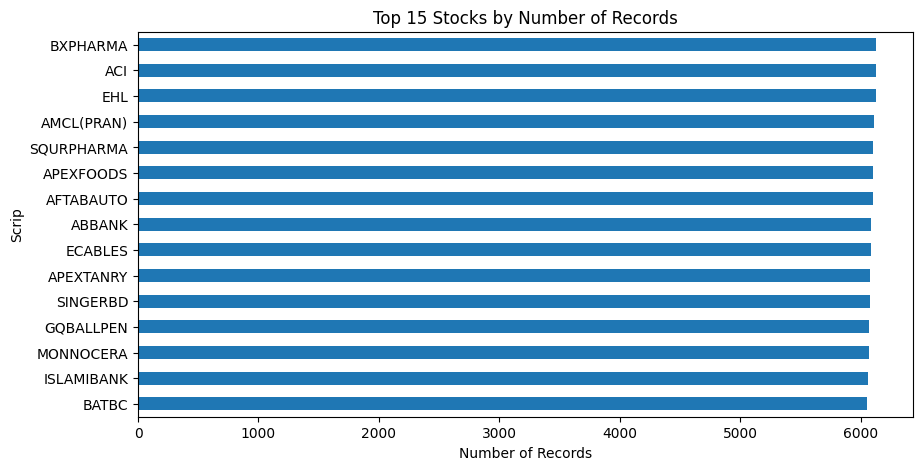

In [11]:
top_stocks = df["Scrip"].value_counts().head(15)

plt.figure(figsize=(10, 5))
top_stocks.sort_values().plot(kind="barh")

plt.title("Top 15 Stocks by Number of Records")
plt.xlabel("Number of Records")
plt.show()

# **Single Stock Price Trend**

The closing price of a selected stock is plotted against time.

This visualization helps us observe:

- Long-term price movement
- Upward and downward trends
- Periods of high volatility
- Major changes in the stock price

The analysis is performed on an individual stock to make the time-series behavior easier to interpret.

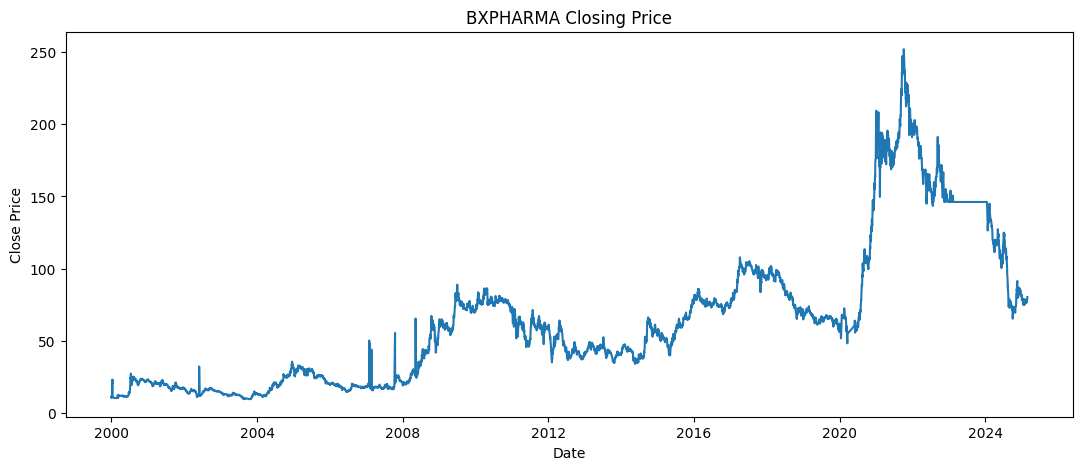

In [12]:
stock = "BXPHARMA"

data = df[df["Scrip"] == stock].copy()
data = data.sort_values("Date")

plt.figure(figsize=(13, 5))
plt.plot(data["Date"], data["Close"])

plt.title(f"{stock} Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

# **Trading Volume**

Trading volume represents the amount of trading activity associated with a stock.

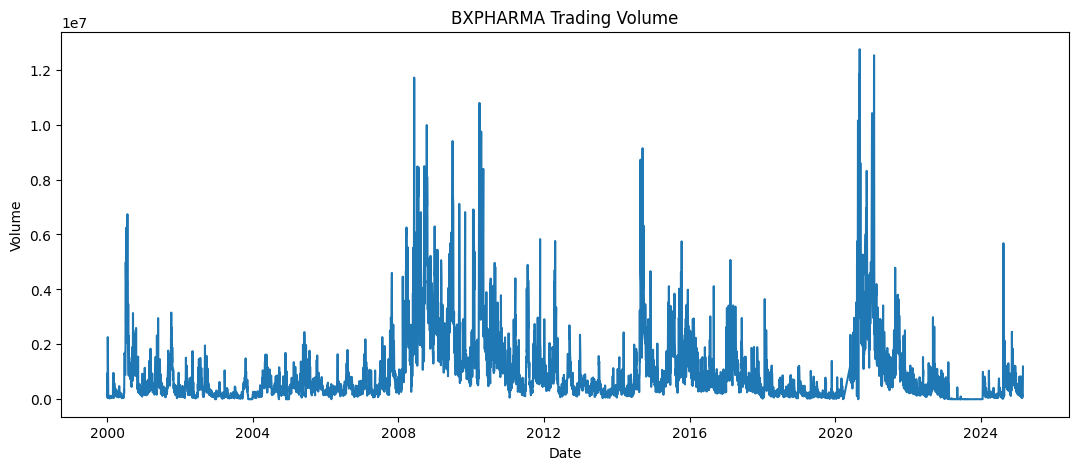

In [13]:
plt.figure(figsize=(13, 5))
plt.plot(data["Date"], data["Volume"])

plt.title(f"{stock} Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

# **Daily Return**

Daily return measures the percentage change in the closing price from one trading observation to the next.

It is calculated as:

Daily Return = (Current Close − Previous Close) / Previous Close

Returns are more useful than raw prices for measuring short-term market movement because they represent relative changes in price.

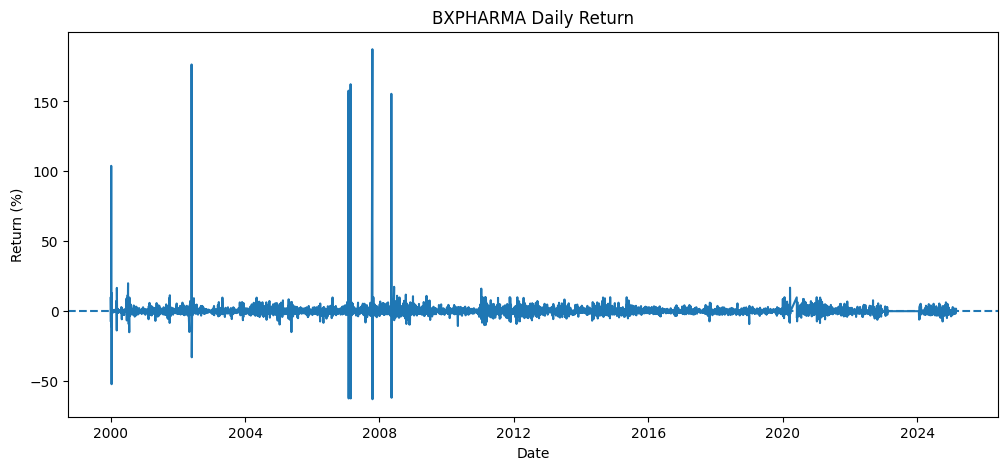

In [14]:
data["Return"] = data["Close"].pct_change() * 100

plt.figure(figsize=(12, 5))
plt.plot(data["Date"], data["Return"])

plt.axhline(0, linestyle="--")

plt.title(f"{stock} Daily Return")
plt.xlabel("Date")
plt.ylabel("Return (%)")
plt.show()

# **Return Distribution**

The distribution of daily returns is visualized using a histogram.


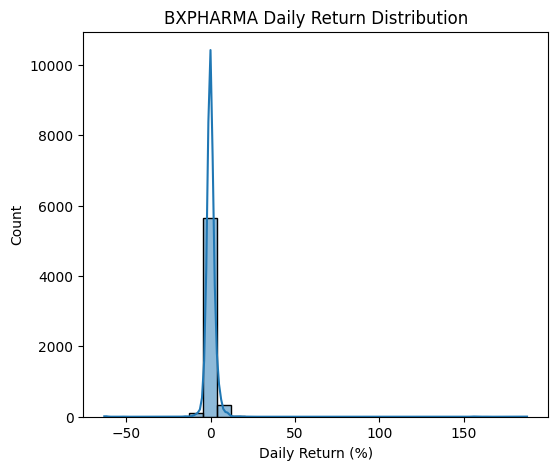

In [15]:
plt.figure(figsize=(6, 5))

sns.histplot(data["Return"].dropna(),bins=30,kde=True)

plt.title(f"{stock} Daily Return Distribution")
plt.xlabel("Daily Return (%)")
plt.show()

# **Rolling Volatility**

A 20-day rolling standard deviation of returns is calculated to measure changing market volatility.

Higher volatility indicates larger fluctuations in returns, while lower volatility indicates more stable price movement.

Volatility is later used as a predictive feature.

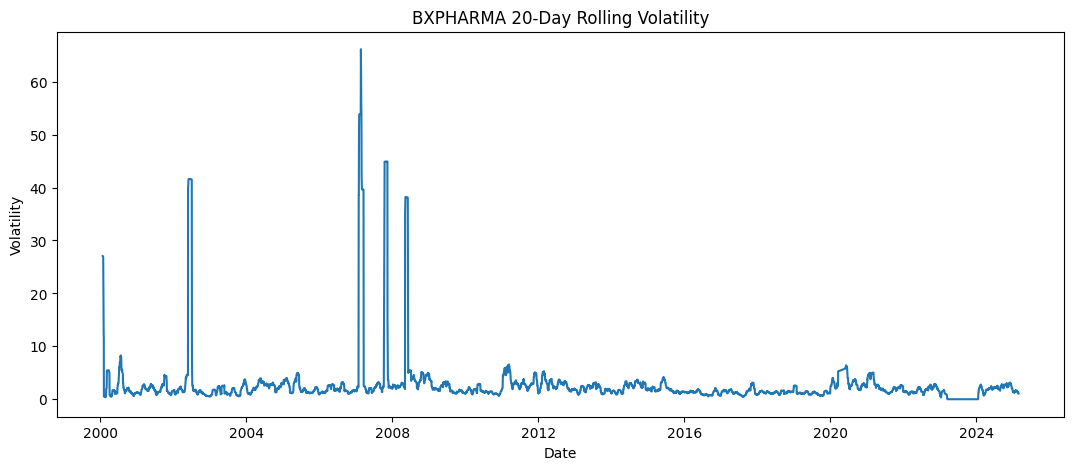

In [16]:
data["Volatility"] = data["Return"].rolling(20).std()

plt.figure(figsize=(13, 5))
plt.plot(data["Date"], data["Volatility"])

plt.title(f"{stock} 20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()

# **Volume vs Daily Return**

The relationship between trading volume and daily return is visualized using a scatter plot.

The purpose is to explore whether changes in trading activity appear to be associated with changes in stock returns.

This is exploratory and does not establish a causal relationship.

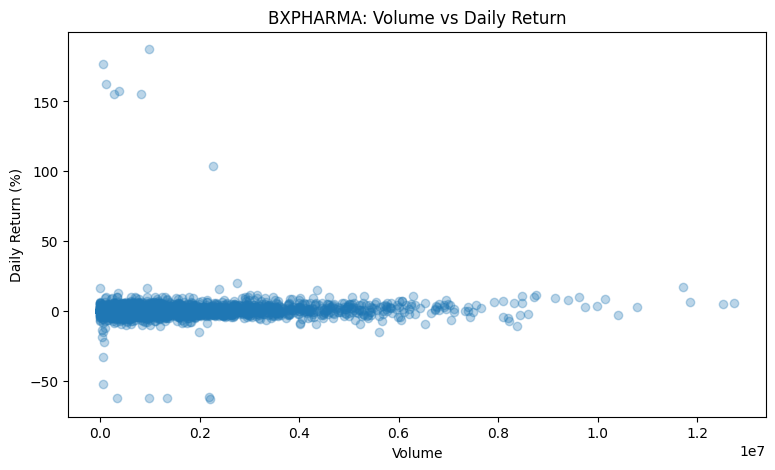

In [17]:
plt.figure(figsize=(9, 5))

plt.scatter(data["Volume"],data["Return"],alpha=0.3)

plt.xlabel("Volume")
plt.ylabel("Daily Return (%)")
plt.title(f"{stock}: Volume vs Daily Return")

plt.show()

# **High-Low Price Range**

The normalized difference between the daily high and low prices is calculated.

Price Range = (High − Low) / Close

This feature represents the magnitude of intraday price movement relative to the closing price.

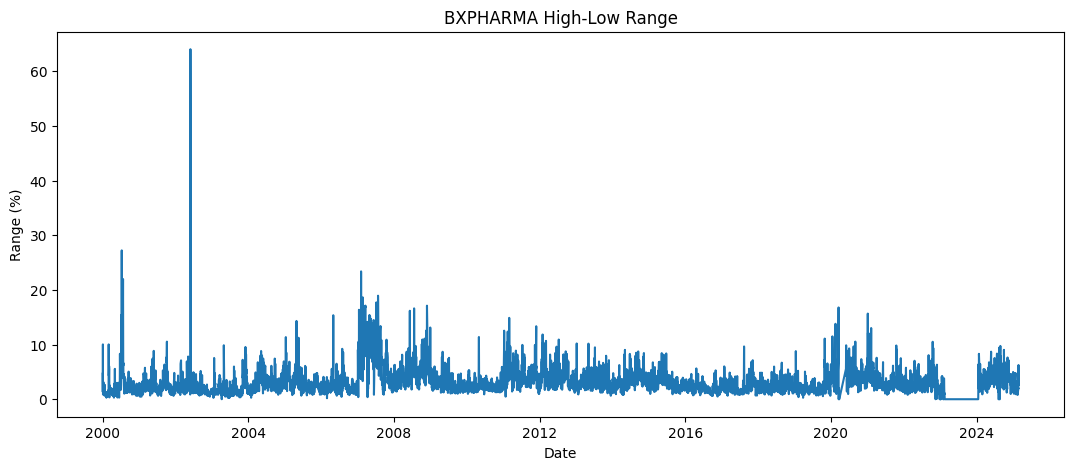

In [18]:
data["Range"] = ((data["High"] - data["Low"]) / data["Close"]) * 100

plt.figure(figsize=(13, 5))
plt.plot(data["Date"], data["Range"])

plt.title(f"{stock} High-Low Range")
plt.xlabel("Date")
plt.ylabel("Range (%)")
plt.show()

# **OHLC Price Trend**

The Open, High, Low, and Close prices are plotted together for the selected stock.

This allows us to compare different components of daily price behavior and visually identify periods of increased or decreased market movement.

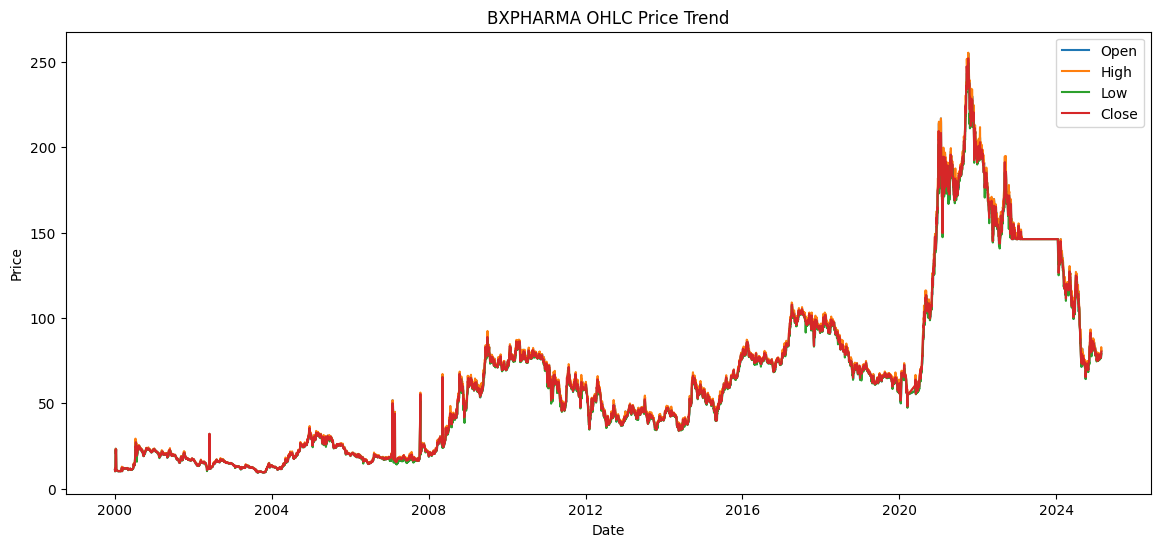

In [19]:
stock = "BXPHARMA"

data = df[df["Scrip"] == stock].copy()
data = data.sort_values("Date")

plt.figure(figsize=(14, 6))

plt.plot(data["Date"], data["Open"], label="Open")
plt.plot(data["Date"], data["High"], label="High")
plt.plot(data["Date"], data["Low"], label="Low")
plt.plot(data["Date"], data["Close"], label="Close")

plt.title(f"{stock} OHLC Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()

# **Volatility Comparison Across Stocks**

Daily returns are calculated separately for each stock and their standard deviations are used as a measure of volatility.

The most volatile stocks are visualized to compare risk and price variability across different securities in the dataset.

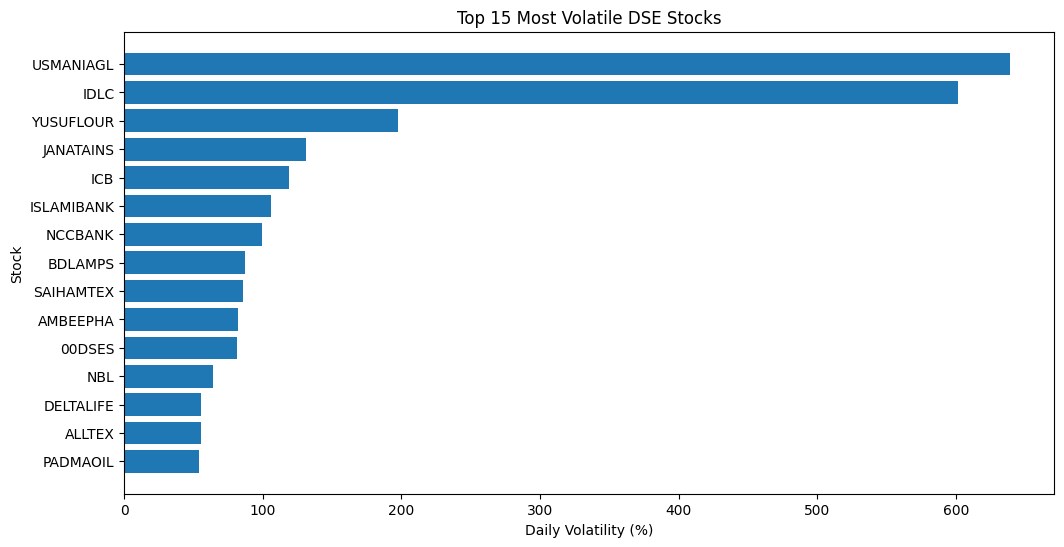

In [20]:
df["Return"] = df.groupby("Scrip")["Close"].pct_change()
volatility = (df.groupby("Scrip")["Return"].std().sort_values(ascending=False))

top_volatility = volatility.head(15).sort_values()

plt.figure(figsize=(12, 6))

plt.barh(top_volatility.index,top_volatility.values * 100)

plt.title("Top 15 Most Volatile DSE Stocks")
plt.xlabel("Daily Volatility (%)")
plt.ylabel("Stock")

plt.show()

# **Return Autocorrelation**

Autocorrelation measures the relationship between a time series and its previous values at different lags.

Here, autocorrelation of returns is examined across multiple lags.

The purpose is to investigate whether previous return behavior contains temporal dependence that may be useful for feature engineering and prediction.

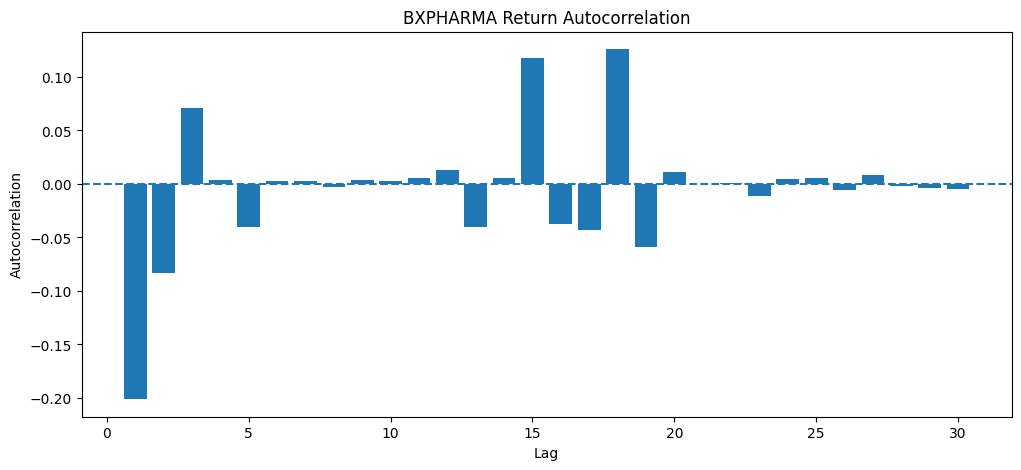

In [21]:
data["Return"] = data["Close"].pct_change()

autocorrelation = []

for lag in range(1, 31):
    value = data["Return"].autocorr(lag=lag)
    autocorrelation.append(value)

plt.figure(figsize=(12, 5))

plt.bar(range(1, 31), autocorrelation)

plt.axhline(0, linestyle="--")

plt.title(f"{stock} Return Autocorrelation")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")

plt.show()

# **OHLCV Correlation Analysis**

A correlation heatmap is used to examine the relationships between Open, High, Low, Close, and Volume.

Correlation values range from -1 to +1:

- +1 indicates a strong positive relationship.
- -1 indicates a strong negative relationship.
- 0 indicates little or no linear relationship.

This helps us understand relationships among the original market variables before creating additional features.

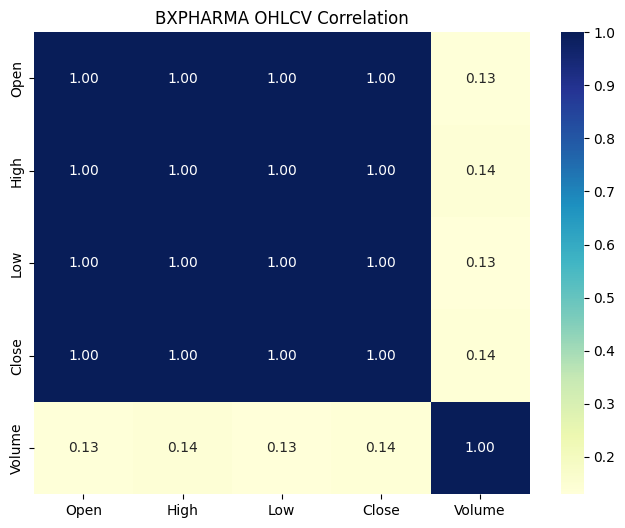

In [22]:
cols = ["Open", "High", "Low", "Close", "Volume"]

plt.figure(figsize=(8, 6))

sns.heatmap(data[cols].corr(),annot=True,cmap="YlGnBu",fmt=".2f")

plt.title(f"{stock} OHLCV Correlation")
plt.show()

# **Feature Engineering**

Feature engineering is the process of transforming raw market data into meaningful variables that may contain information about future stock direction.

Since stock prices are time-dependent, the features are calculated separately for each stock using chronological observations.

The engineered features include:

- Daily Return
- Lag Features
- Moving Averages
- Exponential Moving Averages
- Rolling Volatility
- Price Range
- Volume Features
- RSI
- MACD
- Bollinger Bands
- ATR
- ROC

<br></br>

### Daily Return

Daily return is calculated separately for each stock using the percentage change in closing price.

This feature captures the recent price movement of each security and provides a normalized representation of price change.

In [23]:
df = df.sort_values(["Scrip", "Date"]).copy()

In [24]:
df["Return"] = df.groupby("Scrip")["Close"].pct_change()

### Lag Features

Lag features represent previous observations of price and return.

Examples include:

- Previous day's return
- Two-day lagged return
- Five-day lagged return

Lagged information is important in time-series prediction because the model can use historical behavior to predict future movement.

All lag features are calculated separately for each stock to prevent information from one stock from entering another stock's historical sequence.

In [25]:
df["Close_Lag1"] = df.groupby("Scrip")["Close"].shift(1)
df["Close_Lag2"] = df.groupby("Scrip")["Close"].shift(2)
df["Close_Lag3"] = df.groupby("Scrip")["Close"].shift(3)
df["Close_Lag5"] = df.groupby("Scrip")["Close"].shift(5)

df["Return_Lag1"] = df.groupby("Scrip")["Return"].shift(1)
df["Return_Lag2"] = df.groupby("Scrip")["Return"].shift(2)
df["Return_Lag5"] = df.groupby("Scrip")["Return"].shift(5)

### Moving Average Features

Moving averages are calculated over different time windows.

The project uses:

- 5-day SMA
- 20-day SMA
- 50-day SMA

Moving averages smooth short-term fluctuations and help represent the underlying price trend over different time horizons.

In [26]:
df["SMA_5"] = df.groupby("Scrip")["Close"].rolling(5).mean().reset_index(level=0, drop=True)

df["SMA_20"] = df.groupby("Scrip")["Close"].rolling(20).mean().reset_index(level=0, drop=True)

df["SMA_50"] = df.groupby("Scrip")["Close"].rolling(50).mean().reset_index(level=0, drop=True)

### Exponential Moving Average

Exponential Moving Averages give greater weight to more recent observations compared with simple moving averages.

The project calculates:

- EMA 12
- EMA 26

These features are commonly used to capture short- and medium-term price trends.

In [27]:
df["EMA_12"] = df.groupby("Scrip")["Close"].transform(lambda x: x.ewm(span=12).mean())

df["EMA_26"] = df.groupby("Scrip")["Close"].transform(lambda x: x.ewm(span=26).mean())

### Rolling Volatility Features

Rolling volatility is calculated using the standard deviation of returns over different windows.

The project uses:

- 5-day volatility
- 20-day volatility

These features represent short-term and medium-term changes in market uncertainty.

In [28]:
df["Volatility_5"] = (df.groupby("Scrip")["Return"].transform(lambda x: x.rolling(5).std()))

df["Volatility_20"] = (df.groupby("Scrip")["Return"].transform(lambda x: x.rolling(20).std()))

### Price Range

Price range measures the intraday movement between the high and low prices relative to the closing price.

Price Range = (High − Low) / Close

A larger value indicates greater intraday price movement.

In [29]:
df["Price_Range"] = ((df["High"] - df["Low"]) / df["Close"])

### Volume-Based Features

Two volume-related features are created:

- Volume Change
- 20-day Volume SMA

Volume Change captures the relative change in trading volume, while the 20-day moving average provides a smoother representation of recent trading activity.

In [30]:
df["Volume_Change"] = (df.groupby("Scrip")["Volume"].pct_change())
df["Volume_SMA_20"] = (df.groupby("Scrip")["Volume"].transform(lambda x: x.rolling(20).mean()))

In [31]:
# Replace inf values with NaN
df["Volume_Change"] = df["Volume_Change"].replace(
    [np.inf, -np.inf],
    np.nan
)

# Create a robust volume-change feature
df["Volume_Change_Robust"] = (
    df.groupby("Scrip")["Volume"]
      .transform(lambda x: np.log1p(x).diff())
)

print("Original Volume_Change:")
display(
    df["Volume_Change"].describe()
)

print("\nRobust Volume_Change:")
display(
    df["Volume_Change_Robust"].describe()
)

print(
    "\nRemaining infinite values:",
    np.isinf(
        df["Volume_Change_Robust"]
    ).sum()
)

Original Volume_Change:


count    1.380517e+06
mean     2.670392e+01
std      4.635608e+03
min     -1.000000e+00
25%     -3.888889e-01
50%     -2.269809e-02
75%      6.017393e-01
max      4.761934e+06
Name: Volume_Change, dtype: float64


Robust Volume_Change:


count    1.381107e+06
mean     4.039798e-05
std      1.204023e+00
min     -2.475003e+01
25%     -4.918350e-01
50%     -2.253585e-02
75%      4.712517e-01
max      2.448478e+01
Name: Volume_Change_Robust, dtype: float64


Remaining infinite values: 0


### Technical Indicators

Additional technical indicators are generated to capture momentum, trend, volatility, and price behavior.

The indicators include:

- **RSI (Relative Strength Index):** measures momentum and helps identify relatively strong or weak price movement.
- **MACD:** captures trend and momentum using the relationship between moving averages.
- **MACD Signal:** a smoothed version of MACD used to identify momentum changes.
- **MACD Histogram:** represents the difference between MACD and its signal line.
- **Bollinger Bands:** represent price levels relative to a moving average and volatility.
- **ATR (Average True Range):** measures market volatility.
- **ROC (Rate of Change):** measures the percentage change in price over a specified period.

These indicators provide additional information beyond the original OHLCV variables.

In [32]:
def indicators(stock):

   
    if len(stock) < 35:
        stock["RSI"] = float("nan")
        stock["MACD"] = float("nan")
        stock["MACD_Signal"] = float("nan")
        stock["MACD_Hist"] = float("nan")
        stock["BB_High"] = float("nan")
        stock["BB_Low"] = float("nan")
        stock["BB_Middle"] = float("nan")
        stock["ATR"] = float("nan")
        stock["ROC"] = float("nan")

        return stock

    # RSI
    stock["RSI"] = RSIIndicator(
        stock["Close"], window=14
    ).rsi()

    # MACD
    macd = MACD(stock["Close"])

    stock["MACD"] = macd.macd()
    stock["MACD_Signal"] = macd.macd_signal()
    stock["MACD_Hist"] = macd.macd_diff()

    # Bollinger Bands
    bb = BollingerBands(
        stock["Close"],
        window=20
    )

    stock["BB_High"] = bb.bollinger_hband()
    stock["BB_Low"] = bb.bollinger_lband()
    stock["BB_Middle"] = bb.bollinger_mavg()

    # ATR
    atr = AverageTrueRange(
        stock["High"],
        stock["Low"],
        stock["Close"],
        window=14
    )

    stock["ATR"] = atr.average_true_range()

    # ROC
    stock["ROC"] = ROCIndicator(
        stock["Close"],
        window=12
    ).roc()

    return stock

In [33]:
df = df.sort_values(["Scrip", "Date"])

df = df.groupby("Scrip", group_keys=False).apply(indicators)

df = df.reset_index(drop=True)

C:\Users\INTEL\AppData\Local\Temp\ipykernel_8540\2407249385.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("Scrip", group_keys=False).apply(indicators)


In [34]:
df.isnull().sum().sort_values(ascending=False)

SMA_50                  21052
MACD_Hist               14252
MACD_Signal             14252
MACD                    10852
Volatility_20            8727
BB_Low                   8302
BB_Middle                8302
BB_High                  8302
Volume_SMA_20            8301
SMA_20                   8301
RSI                      5752
ROC                      5327
Return_Lag5              2709
Close_Lag5               2265
Volatility_5             2265
SMA_5                    1819
Close_Lag3               1370
Return_Lag2              1370
Volume_Change            1054
Return_Lag1               920
Close_Lag2                920
Return                    464
Volume_Change_Robust      464
Close_Lag1                464
ATR                       227
Date                        0
Scrip                       0
Open                        0
EMA_12                      0
Low                         0
High                        0
Volume                      0
Close                       0
EMA_26    

## Handling Missing Values After Feature Engineering

Technical indicators, lag features, and rolling calculations require previous observations.

Therefore, the beginning of each stock's time series may contain missing values.

After all required features and indicators are created, rows containing missing values are removed so that the machine learning models receive complete observations.

In [35]:
df = df.dropna().reset_index(drop=True)

In [36]:
df.isnull().sum().sort_values(ascending=False)

Date                    0
Scrip                   0
Open                    0
High                    0
Low                     0
Close                   0
Volume                  0
Return                  0
Close_Lag1              0
Close_Lag2              0
Close_Lag3              0
Close_Lag5              0
Return_Lag1             0
Return_Lag2             0
Return_Lag5             0
SMA_5                   0
SMA_20                  0
SMA_50                  0
EMA_12                  0
EMA_26                  0
Volatility_5            0
Volatility_20           0
Price_Range             0
Volume_Change           0
Volume_SMA_20           0
Volume_Change_Robust    0
RSI                     0
MACD                    0
MACD_Signal             0
MACD_Hist               0
BB_High                 0
BB_Low                  0
BB_Middle               0
ATR                     0
ROC                     0
dtype: int64

In [37]:
before = len(df)

df = df.dropna().reset_index(drop=True)

after = len(df)

print("Rows before:", before)
print("Rows after:", after)
print("Rows removed:", before - after)

Rows before: 1359941
Rows after: 1359941
Rows removed: 0


In [38]:
print("Total NaN:", df.isna().sum().sum())

Total NaN: 0


In [39]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values(["Scrip", "Date"]).reset_index(drop=True)

# Creating the Prediction Target

To predict the next trading movement, the next available closing price for each stock is calculated using a one-step forward shift.

The calculation is performed separately for every stock.

This allows the current day's market information to be associated with the following trading observation.

In [40]:
df["Next_Close"] = (df.groupby("Scrip")["Close"].shift(-1))

Direction making

In [41]:
df["Direction"] = 0

df.loc[df["Next_Close"] > df["Close"], "Direction"] = 1

df.loc[df["Next_Close"] < df["Close"], "Direction"] = -1

# Remove Last row

In [42]:
df = df.dropna(subset=["Next_Close"]).reset_index(drop=True)

# Checking The dataset


In [43]:
df[["Scrip", "Date", "Close", "Next_Close", "Direction"]].head(20)


,Scrip,Date,Close,Next_Close,Direction
0,00DS30,2013-04-11,1322.06,1338.45,1
1,00DS30,2013-04-15,1338.45,1318.51,-1
2,00DS30,2013-04-16,1318.51,1321.18,1
3,00DS30,2013-04-17,1321.18,1322.00,1
4,00DS30,2013-04-18,1322.00,1306.58,-1
5,00DS30,2013-04-21,1306.58,1305.59,-1
6,00DS30,2013-04-22,1305.59,1307.46,1
7,00DS30,2013-04-23,1307.46,1307.35,-1
8,00DS30,2013-04-24,1307.35,1308.37,1
9,00DS30,2013-04-25,1308.37,1288.02,-1


In [44]:
df["Direction"].value_counts()

Direction
-1    639888
 1    527165
 0    192463
Name: count, dtype: int64

In [45]:
df = df.drop(columns=["Next_Close"])

In [46]:
df = df.sort_values(["Date", "Scrip"]).reset_index(drop=True)

# Use dates, not row count
unique_dates = np.sort(df["Date"].unique())

# 80% of dates for training
split_idx = int(len(unique_dates) * 0.80)

train_end_date = unique_dates[split_idx - 1]
test_start_date = unique_dates[split_idx]

train_data = df[df["Date"] <= train_end_date].copy()
test_data  = df[df["Date"] >= test_start_date].copy()

print("Train period:")
print(train_data["Date"].min(), "→", train_data["Date"].max())

print("\nTest period:")
print(test_data["Date"].min(), "→", test_data["Date"].max())

print("\nTrain shape:", train_data.shape)
print("Test shape :", test_data.shape)

# Check date overlap
date_overlap = set(train_data["Date"]) & set(test_data["Date"])

print("\nCommon dates between train and test:", len(date_overlap))

Train period:
2000-03-11 00:00:00 → 2019-11-28 00:00:00

Test period:
2019-12-01 00:00:00 → 2025-02-25 00:00:00

Train shape: (904533, 36)
Test shape : (454983, 36)

Common dates between train and test: 0


In [47]:
print("Train:", train_data.shape)
print("Test :", test_data.shape)

print("\nTrain period:")
print(train_data["Date"].min(), "to", train_data["Date"].max())

print("\nTest period:")
print(test_data["Date"].min(), "to", test_data["Date"].max())

Train: (904533, 36)
Test : (454983, 36)

Train period:
2000-03-11 00:00:00 to 2019-11-28 00:00:00

Test period:
2019-12-01 00:00:00 to 2025-02-25 00:00:00


## **Dataset Spliting**

In [48]:
X = train_data.drop(columns=["Direction", "Date", "Scrip"])
y = train_data["Direction"]

Creating Time-Series CV

In [49]:
tscv = TimeSeriesSplit(n_splits=5)

Check the Fold

In [50]:
for fold_number, (train_index, val_index) in enumerate(tscv.split(X), start=1):

    print(f"\n--- Fold {fold_number} ---")

    print("Training rows:", train_index[0], "to", train_index[-1])
    print("Validation rows:", val_index[0], "to", val_index[-1])


--- Fold 1 ---
Training rows: 0 to 150757
Validation rows: 150758 to 301512

--- Fold 2 ---
Training rows: 0 to 301512
Validation rows: 301513 to 452267

--- Fold 3 ---
Training rows: 0 to 452267
Validation rows: 452268 to 603022

--- Fold 4 ---
Training rows: 0 to 603022
Validation rows: 603023 to 753777

--- Fold 5 ---
Training rows: 0 to 753777
Validation rows: 753778 to 904532


In [51]:
x_train = train_data.drop(columns=["Direction", "Date", "Scrip"])
y_train = train_data["Direction"]

## **Applying Boruta**

In [52]:
# 1. Create Robust Volume Change
df["Volume_Change"] = df["Volume_Change"].replace([np.inf, -np.inf],np.nan)
df["Volume_Change_Robust"] = (df.groupby("Scrip")["Volume"].transform(lambda x: np.log1p(x).diff()))

# 2. IMPORTANT:
# Re-create train/test AFTER adding the new feature


df = df.sort_values(
    ["Date", "Scrip"]
).reset_index(drop=True)

unique_dates = np.sort(df["Date"].unique())

split_idx = int(len(unique_dates) * 0.80)

train_end_date = unique_dates[split_idx - 1]
test_start_date = unique_dates[split_idx]

train_data = df[df["Date"] <= train_end_date].copy()

test_data = df[df["Date"] >= test_start_date].copy()


# 3. Take chronological TRAIN-only sample for Boruta

boruta_sample = (train_data.sort_values(["Date", "Scrip"]).head(100000).copy())

# 4. Separate features and target


x_boruta = boruta_sample.drop(columns=["Direction", "Date", "Scrip"])

y_boruta = boruta_sample["Direction"]



# 5. Handle infinity


x_boruta = x_boruta.replace([np.inf, -np.inf],np.nan)



# 6. Remove rows containing NaN


valid_rows = x_boruta.notna().all(axis=1)

x_boruta = x_boruta.loc[valid_rows]
y_boruta = y_boruta.loc[valid_rows]



# 7. Check Boruta data


print("Boruta rows:", len(x_boruta))
print("Boruta columns:", x_boruta.shape[1])

print("Boruta period:",boruta_sample["Date"].min(), "→",boruta_sample["Date"].max())

print("NaN values:",x_boruta.isna().sum().sum())
print("Infinity values:",np.isinf(x_boruta).sum().sum())

# 8. Random Forest for Boruta

rf = RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1,class_weight="balanced")


# 9. Boruta


boruta = BorutaPy(estimator=rf,n_estimators="auto",verbose=2,random_state=42)



# 10. Run Boruta


boruta.fit(x_boruta.values,y_boruta.values)



# 11. Confirmed features


selected_features = x_boruta.columns[boruta.support_]

print("\nConfirmed Features:")
print(selected_features.tolist())

print(
    "\nNumber of confirmed features:",len(selected_features))

# 12. Tentative features


tentative_features = x_boruta.columns[boruta.support_weak_]

print("\nTentative Features:")
print(tentative_features.tolist())

print("\nNumber of tentative features:",len(tentative_features))

Boruta rows: 99911
Boruta columns: 33
Boruta period: 2000-03-11 00:00:00 → 2006-08-29 00:00:00
NaN values: 0
Infinity values: 0
Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	33
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	33
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	33
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	33
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	33
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	33
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	33
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	10
Tentative: 	2
Rejected: 	21
Iteration: 	9 / 100
Confirmed: 	10
Tentative: 	2
Rejected: 	21
Iteration: 	10 / 100
Confirmed: 	10
Tentative: 	2
Rejected: 	21
Iteration: 	11 / 100
Confirmed: 	10
Tentative: 	2
Rejected: 	21
Iteration: 	12 / 100
Confirmed: 	10
Tentative: 	2
Rejected: 	21
Iteration: 	13 / 100
Confirmed: 	10
Tentative: 	2
Rejected: 	21
Iteration: 	14 / 100
Confirmed: 	10
Tentative: 	2
Reject

## Understanding Boruta Though the plot

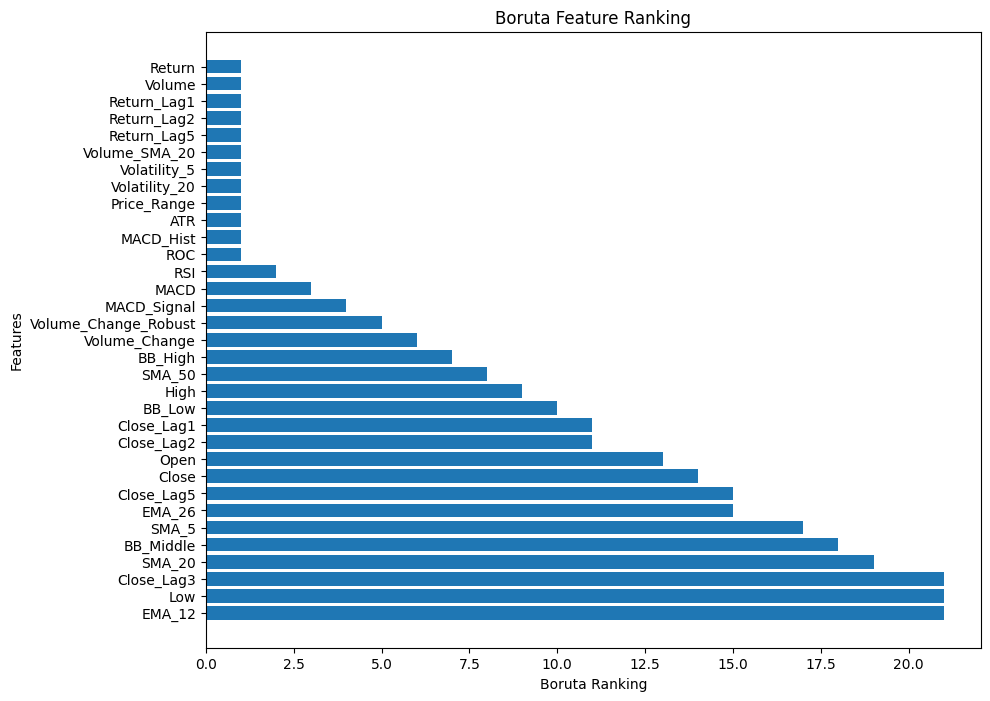

In [53]:
feature_ranking = pd.DataFrame({"Feature": x_boruta.columns,"Ranking": boruta.ranking_})

feature_ranking = feature_ranking.sort_values("Ranking")

plt.figure(figsize=(10, 8))

plt.barh(feature_ranking["Feature"],feature_ranking["Ranking"])

plt.xlabel("Boruta Ranking")
plt.ylabel("Features")
plt.title("Boruta Feature Ranking")

plt.gca().invert_yaxis()

plt.show()

In [54]:
# 1. Get Boruta confirmed features
selected_features = x_boruta.columns[boruta.support_]

print("Selected features:")
print(selected_features.tolist())
print("\nNumber of selected features:", len(selected_features))

Selected features:
['Volume', 'Return', 'Return_Lag1', 'Return_Lag2', 'Return_Lag5', 'Volatility_5', 'Volatility_20', 'Price_Range', 'Volume_SMA_20', 'MACD_Hist', 'ATR', 'ROC']

Number of selected features: 12


In [55]:
# Training data
xtrain = train_data[selected_features].copy()
ytrain = train_data["Direction"].copy()

#Testing data

xtest = test_data[selected_features].copy()
ytest = test_data["Direction"].copy()

In [56]:
# 4. Handle infinity
xtrain = xtrain.replace([np.inf, -np.inf],np.nan)

xtest = xtest.replace([np.inf, -np.inf],np.nan)


In [57]:
# 5. Fill missing values
# Median calculated ONLY from training data

train_medians = xtrain.median()

xtrain = xtrain.fillna(train_medians)

xtest = xtest.fillna(train_medians)


In [58]:
# 6. Final checks
print("FINAL DATA CHECK")

print("\nxtrain shape:", xtrain.shape)
print("ytrain shape:", ytrain.shape)

print("\nxtest shape:", xtest.shape)
print("ytest shape:", ytest.shape)


print("\nNaN in xtrain:", xtrain.isna().sum().sum())
print("NaN in xtest :", xtest.isna().sum().sum())

print(
    "\nInf in xtrain:",
    np.isinf(xtrain.select_dtypes(include=np.number)).sum().sum()
)

print(
    "Inf in xtest :",
    np.isinf(xtest.select_dtypes(include=np.number)).sum().sum()
)


FINAL DATA CHECK

xtrain shape: (904533, 12)
ytrain shape: (904533,)

xtest shape: (454983, 12)
ytest shape: (454983,)

NaN in xtrain: 0
NaN in xtest : 0

Inf in xtrain: 0
Inf in xtest : 0


In [59]:
# 7. Target distribution

print("\nTrain target:")
print(ytrain.value_counts().sort_index())

print("\nTest target:")
print(ytest.value_counts().sort_index())


Train target:
Direction
-1    447790
 0     79065
 1    377678
Name: count, dtype: int64

Test target:
Direction
-1    192098
 0    113398
 1    149487
Name: count, dtype: int64


In [60]:
#Final confirmation

if (xtrain.isna().sum().sum() == 0and xtest.isna().sum().sum() == 0and np.isinf(xtrain.select_dtypes(include=np.number)).sum().sum() == 0and np.isinf(xtest.select_dtypes(include=np.number)).sum().sum() == 0):
    print("\n xtrain, xtest, ytrain, ytest READY")
else:
    print("\n CHECK NaN/Infinity above")


 xtrain, xtest, ytrain, ytest READY


<>:3: SyntaxWarning: invalid decimal literal
<>:3: SyntaxWarning: invalid decimal literal
<>:3: SyntaxWarning: invalid decimal literal
<>:3: SyntaxWarning: invalid decimal literal
<>:3: SyntaxWarning: invalid decimal literal
<>:3: SyntaxWarning: invalid decimal literal
C:\Users\INTEL\AppData\Local\Temp\ipykernel_8540\3157503363.py:3: SyntaxWarning: invalid decimal literal
  if (xtrain.isna().sum().sum() == 0and xtest.isna().sum().sum() == 0and np.isinf(xtrain.select_dtypes(include=np.number)).sum().sum() == 0and np.isinf(xtest.select_dtypes(include=np.number)).sum().sum() == 0):
C:\Users\INTEL\AppData\Local\Temp\ipykernel_8540\3157503363.py:3: SyntaxWarning: invalid decimal literal
  if (xtrain.isna().sum().sum() == 0and xtest.isna().sum().sum() == 0and np.isinf(xtrain.select_dtypes(include=np.number)).sum().sum() == 0and np.isinf(xtest.select_dtypes(include=np.number)).sum().sum() == 0):
C:\Users\INTEL\AppData\Local\Temp\ipykernel_8540\3157503363.py:3: SyntaxWarning: invalid decimal l

## Model Train and Test And Evaluation

# Performing LogisticRegression

In [61]:
lr= LogisticRegression(C=1.0,solver="lbfgs",max_iter=10000,class_weight="balanced",random_state=42)

model_lr= lr.fit(xtrain,ytrain)

#Training Score 
print("Training Score : ", model_lr.score(xtrain,ytrain)*100)

#Test Score 
print("Testing Score : ", model_lr.score(xtest,ytest)*100)


Training Score :  44.439285244429996
Testing Score :  36.21717734508762


# Evaluation

Accuracy Score for LogisticRegression :  41.79079218344421
Classification Report               precision    recall  f1-score   support

          -1       0.00      0.00      0.00         0
           0       0.42      0.99      0.59    192098
           1       0.00      0.00      0.00    113398
           2       0.00      0.00      0.00    149487

    accuracy                           0.42    454983
   macro avg       0.11      0.25      0.15    454983
weighted avg       0.18      0.42      0.25    454983



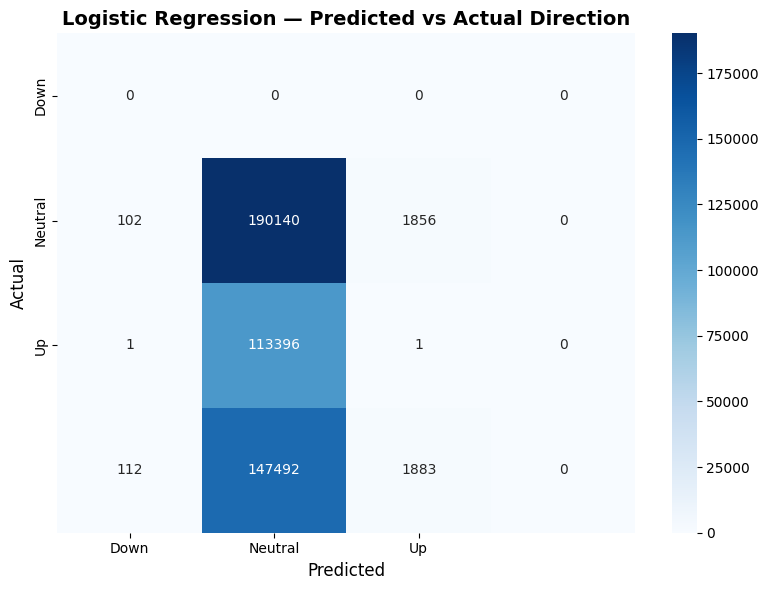

In [122]:
# Prediction
y_pred_lr = lr.predict(xtest)

# accuracy score 
acc_lr = accuracy_score(ytest,y_pred_lr)
print("Accuracy Score for LogisticRegression : ",acc_lr*100)


#Classification Report
class_rep_lr = classification_report(ytest,y_pred_lr)
print("Classification Report", class_rep_lr)

# Confusion Matrix
con_max_lr = confusion_matrix(ytest,y_pred_lr)

#heatmap 
plt.figure(figsize=(8, 6))
sns.heatmap(con_max_lr, annot=True, fmt='d', cmap="Blues",xticklabels=["Down", "Neutral", "Up"],yticklabels=["Down", "Neutral", "Up"])
plt.title("Logistic Regression — Predicted vs Actual Direction", fontsize=14, fontweight='bold')
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.tight_layout()
plt.show()

Accuracy : 41.79079218344421
Precision: 17.805748316472858
Recall   : 41.79079218344421
F1 Score : 24.96562793136878
ROC-AUC  : 62.31480173993923


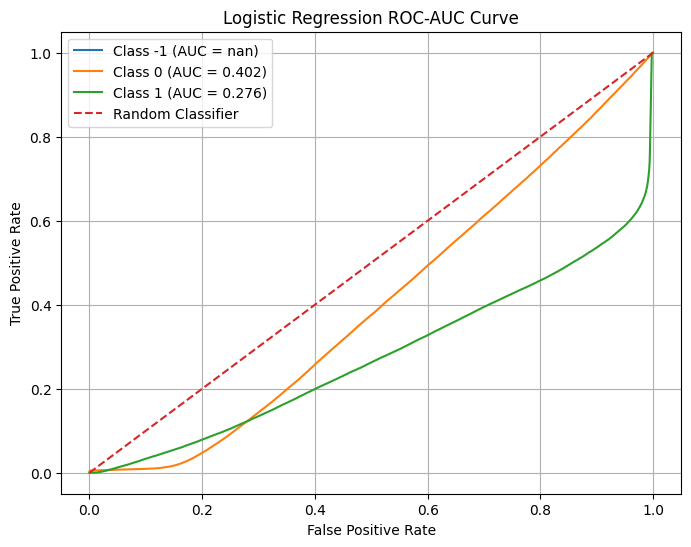

In [123]:
# Predictions
y_pred_lr = lr.predict(xtest)

# Probability predictions
y_prob = model_lr.predict_proba(xtest)

# Accuracy
accuracy = accuracy_score(ytest, y_pred_lr)

# Precision
precision = precision_score(ytest,y_pred_lr,average="weighted",zero_division=0)

# Recall
recall = recall_score(ytest,y_pred_lr,average="weighted",zero_division=0)

# F1 Score
f1 = f1_score(ytest,y_pred_lr,average="weighted",zero_division=0)

# ROC-AUC
roc_auc = roc_auc_score(ytest,y_prob,multi_class="ovr",average="weighted")

print("Accuracy :", accuracy*100)
print("Precision:", precision*100)
print("Recall   :", recall*100)
print("F1 Score :", f1*100)
print("ROC-AUC  :", roc_auc*100)


import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# ROC-AUC Curve for Multiclass Classification

import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


# Our three classes
classes = [-1, 0, 1]


# Convert the actual labels into binary form
# This is required for calculating ROC curve for each class
ytest_bin = label_binarize(ytest, classes=classes)


# Create the ROC curve
plt.figure(figsize=(8, 6))


# Calculate ROC curve separately for each class
for i in range(len(classes)):

    # False Positive Rate and True Positive Rate
    fpr, tpr, thresholds = roc_curve(ytest_bin[:, i], y_prob[:, i])

    # Calculate AUC
    auc_score = auc(fpr, tpr)

    # Plot ROC curve
    plt.plot(fpr,tpr,label=f"Class {classes[i]} (AUC = {auc_score:.3f})")


# Random classifier reference line
plt.plot([0, 1],[0, 1],linestyle="--",label="Random Classifier")


# Graph labels
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC-AUC Curve")


# Show legend and grid
plt.legend()
plt.grid(True)


# Display the graph
plt.show()

<br></br>

#  Performing Random Forest 

In [63]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

model_rf = rf.fit(xtrain,ytrain)

#Training Score 
print("Training Score For Random Forest : ", model_rf.score(xtrain,ytrain)*100)

#Test Score 
print("Testing Score For Random Forest : ", model_rf.score(xtest,ytest)*100)

Training Score For Random Forest :  43.98136939171926
Testing Score For Random Forest :  53.87432057901065


# Evaluation

Accuracy Score for Random Forest :  53.87432057901065
Classification Report               precision    recall  f1-score   support

          -1       0.56      0.50      0.53    192098
           0       0.58      0.83      0.68    113398
           1       0.45      0.37      0.40    149487

    accuracy                           0.54    454983
   macro avg       0.53      0.57      0.54    454983
weighted avg       0.53      0.54      0.53    454983



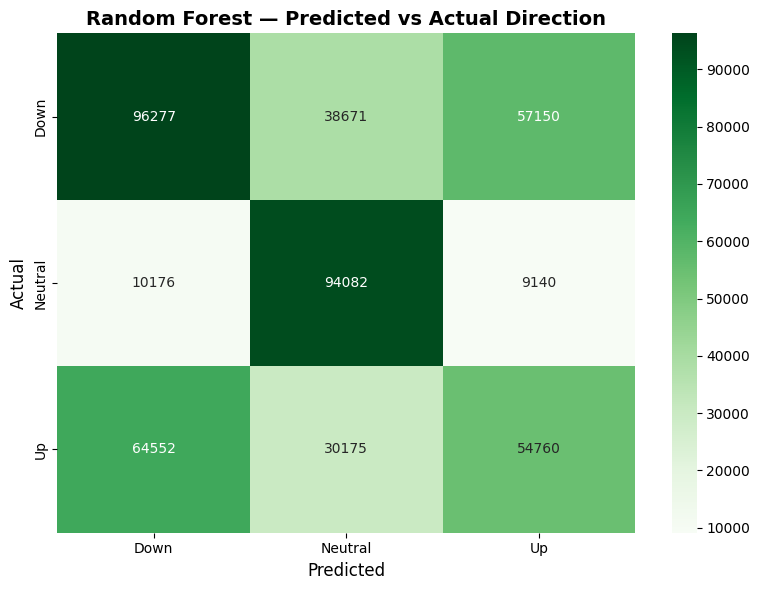

In [64]:
# Prediction
y_pred_rf = rf.predict(xtest)

# accuracy score 
acc_rf = accuracy_score(ytest,y_pred_rf)
print("Accuracy Score for Random Forest : ",acc_rf*100)


#Classification Report
class_rep_rf = classification_report(ytest,y_pred_rf)
print("Classification Report", class_rep_rf)

# Confusion Matrix
con_max_rf = confusion_matrix(ytest,y_pred_rf)

#heatmap 
plt.figure(figsize=(8, 6))
sns.heatmap(con_max_rf, annot=True, fmt='d', cmap="Greens",xticklabels=["Down", "Neutral", "Up"],yticklabels=["Down", "Neutral", "Up"])
plt.title("Random Forest — Predicted vs Actual Direction", fontsize=14, fontweight='bold')
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.tight_layout()
plt.show()



Accuracy : 33.284320513074114
Precision: 17.572224539038924
Recall   : 33.284320513074114
F1 Score : 22.828047067373753
ROC-AUC  : 61.694616725943376


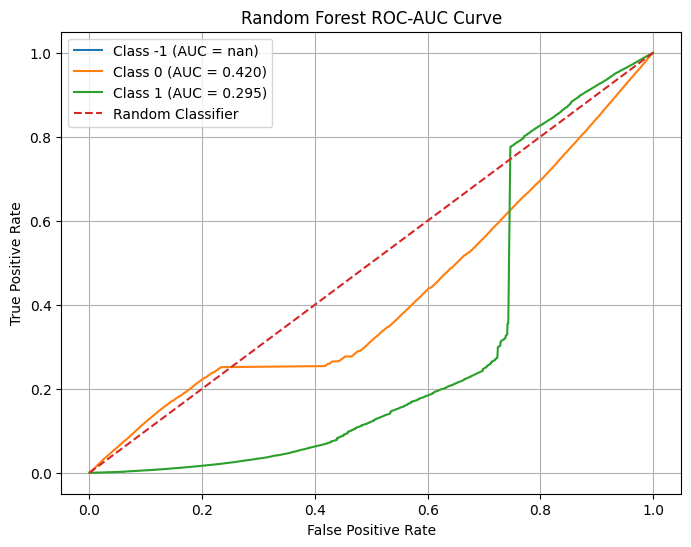

In [133]:
# Predictions
y_pred_rf = model_rf.predict(xtest)

# Probability predictions
y_prob_rf = model_rf.predict_proba(xtest)


# Accuracy
accuracy = accuracy_score(ytest, y_pred_rf)

# Precision
precision = precision_score(ytest,y_pred_rf,average="weighted",zero_division=0)

# Recall
recall = recall_score(ytest,y_pred_rf,average="weighted",zero_division=0)

# F1 Score
f1 = f1_score(ytest,y_pred_rf,average="weighted",zero_division=0)

# ROC-AUC
roc_auc = roc_auc_score(ytest,y_prob_rf,multi_class="ovr",average="weighted")

print("Accuracy :", accuracy * 100)
print("Precision:", precision * 100)
print("Recall   :", recall * 100)
print("F1 Score :", f1 * 100)
print("ROC-AUC  :", roc_auc * 100)


# Classes
classes = [-1, 0, 1]

# Convert actual labels into binary form
ytest_bin = label_binarize(ytest, classes=classes)


# ROC-AUC Curve
plt.figure(figsize=(8, 6))

for i in range(len(classes)):

    fpr, tpr, thresholds = roc_curve(ytest_bin[:, i],y_prob_rf[:, i])

    auc_score = auc(fpr, tpr)

    plt.plot(fpr,tpr,label=f"Class {classes[i]} (AUC = {auc_score:.3f})")


# Random classifier
plt.plot([0, 1],[0, 1],linestyle="--",label="Random Classifier")


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC-AUC Curve")

plt.legend()
plt.grid(True)

plt.show()

<br></br>

# Performing Decision Tree Classifier

In [65]:
dt = DecisionTreeClassifier(
    criterion="gini",
    splitter="best",
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features=None,
    class_weight="balanced",
    ccp_alpha=0.0001,
    random_state=42
)

model_dt = dt.fit(xtrain, ytrain)

print("Training Score:", model_dt.score(xtrain, ytrain) * 100)
print("Testing Score:", model_dt.score(xtest, ytest) * 100)

Training Score: 39.58285656797486
Testing Score: 50.19704032897933


# Evaluation

Accuracy Score for Decision Tree Classifier :  50.19704032897933
Classification Report               precision    recall  f1-score   support

          -1       0.52      0.42      0.47    192098
           0       0.54      0.80      0.65    113398
           1       0.43      0.38      0.40    149487

    accuracy                           0.50    454983
   macro avg       0.50      0.53      0.50    454983
weighted avg       0.50      0.50      0.49    454983



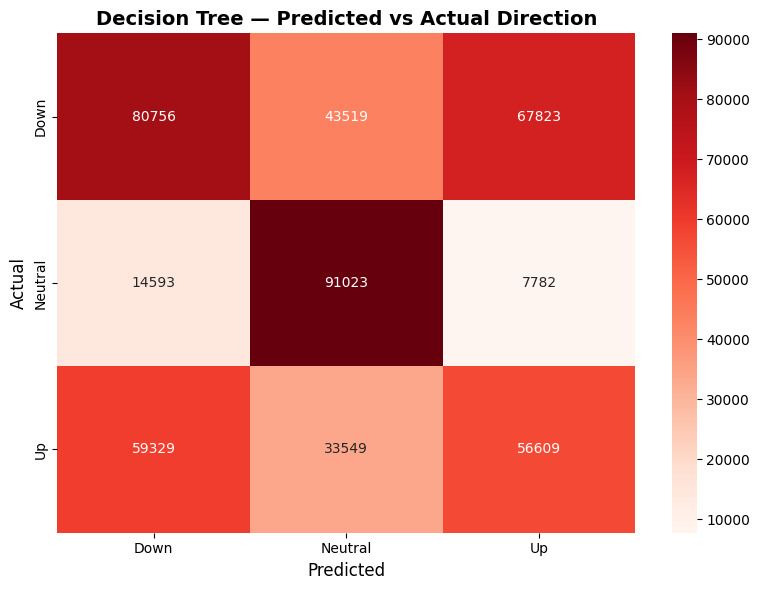

In [66]:
# Prediction
y_pred_dt = dt.predict(xtest)

# accuracy score 
acc_dt = accuracy_score(ytest,y_pred_dt)
print("Accuracy Score for Decision Tree Classifier : ",acc_dt*100)


#Classification Report
class_rep_dt = classification_report(ytest,y_pred_dt)
print("Classification Report", class_rep_dt)

# Confusion Matrix
con_max_dt = confusion_matrix(ytest,y_pred_dt)

#heatmap 
plt.figure(figsize=(8, 6))
sns.heatmap(con_max_dt, annot=True, fmt='d', cmap="Reds",xticklabels=["Down", "Neutral", "Up"],yticklabels=["Down", "Neutral", "Up"])
plt.title("Decision Tree — Predicted vs Actual Direction", fontsize=14, fontweight='bold')
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.tight_layout()
plt.show()


Accuracy : 24.840488545725883
Precision: 24.901436659731804
Recall   : 24.840488545725886
F1 Score : 24.855369740941857
ROC-AUC  : 44.63082996060521


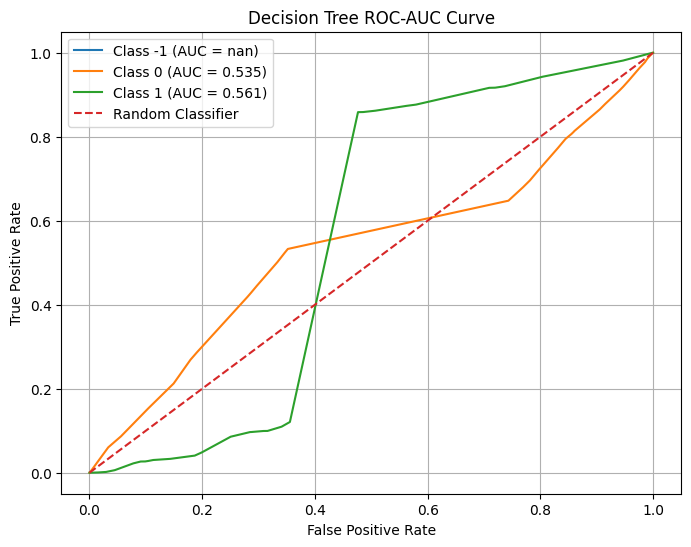

In [128]:
# Predictions
y_pred_dt = model_dt.predict(xtest)

# Probability predictions
y_prob_dt = model_dt.predict_proba(xtest)


# Accuracy
accuracy = accuracy_score(ytest, y_pred_dt)

# Precision
precision = precision_score(
    ytest,
    y_pred_dt,
    average="weighted",
    zero_division=0
)

# Recall
recall = recall_score(
    ytest,
    y_pred_dt,
    average="weighted",
    zero_division=0
)

# F1 Score
f1 = f1_score(
    ytest,
    y_pred_dt,
    average="weighted",
    zero_division=0
)

# ROC-AUC
roc_auc = roc_auc_score(
    ytest,
    y_prob_dt,
    multi_class="ovr",
    average="weighted"
)


print("Accuracy :", accuracy * 100)
print("Precision:", precision * 100)
print("Recall   :", recall * 100)
print("F1 Score :", f1 * 100)
print("ROC-AUC  :", roc_auc * 100)


# Classes
classes = [-1, 0, 1]

# Convert actual labels into binary form
ytest_bin = label_binarize(ytest, classes=classes)


# ROC-AUC Curve
plt.figure(figsize=(8, 6))

for i in range(len(classes)):

    fpr, tpr, thresholds = roc_curve(
        ytest_bin[:, i],
        y_prob_dt[:, i]
    )

    auc_score = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"Class {classes[i]} (AUC = {auc_score:.3f})"
    )


# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC-AUC Curve")

plt.legend()
plt.grid(True)

plt.show()

<br></br>

# Performing XGBoost

In [67]:
# XGBoost target: -1, 0, 1  →  0, 1, 2
ytrain_xgb = ytrain.astype(int).map({-1: 0,0: 1, 1: 2})

ytest_xgb = ytest.astype(int).map({
    -1: 0,
     0: 1,
     1: 2
})



# XGBoost
xgb = XGBClassifier(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=5,
    subsample=0.85,
    colsample_bytree=0.85,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=2.0,
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

# Train
model_xgb = xgb.fit(xtrain,ytrain_xgb)

# Scores
print("Training Score for XGBoost:",model_xgb.score(xtrain, ytrain_xgb)*100)

print("Testing Score for XGBoost:",model_xgb.score(xtest, ytest_xgb)*100)

Training Score for XGBoost: 53.57361201857754
Testing Score for XGBoost: 55.92582580008484


# Evaluation

Accuracy Score for XGBoost :  55.92582580008484
Classification Report               precision    recall  f1-score   support

           0       0.51      0.82      0.63    192098
           1       0.87      0.57      0.69    113398
           2       0.45      0.22      0.30    149487

    accuracy                           0.56    454983
   macro avg       0.61      0.54      0.54    454983
weighted avg       0.58      0.56      0.53    454983



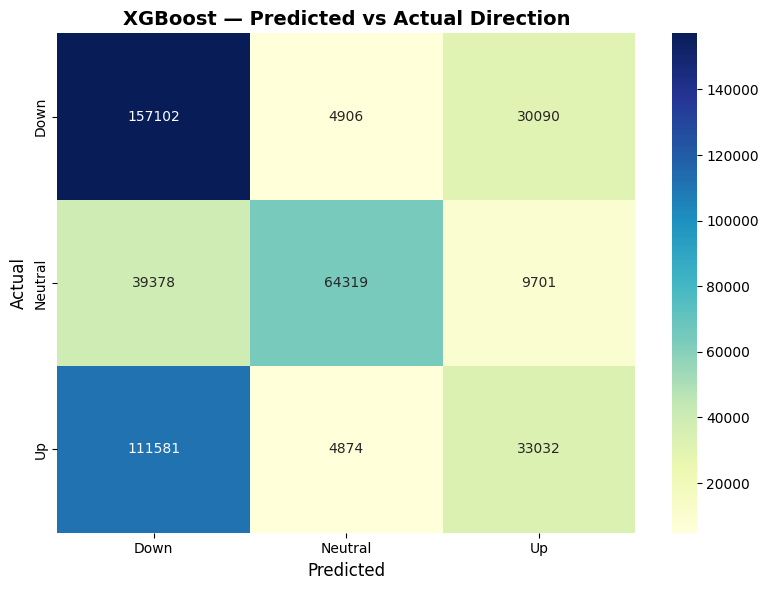

In [68]:
# Prediction
y_pred_xgb = xgb.predict(xtest)

# accuracy score 
acc_xgb = accuracy_score(ytest_xgb,y_pred_xgb)
print("Accuracy Score for XGBoost : ",acc_xgb*100)


#Classification Report
class_rep_xgb = classification_report(ytest_xgb,y_pred_xgb)
print("Classification Report", class_rep_xgb)

# Confusion Matrix
con_max_xgb = confusion_matrix(ytest_xgb,y_pred_xgb)

#heatmap 
plt.figure(figsize=(8, 6))
sns.heatmap(con_max_xgb, annot=True, fmt='d', cmap="YlGnBu",xticklabels=["Down", "Neutral", "Up"],yticklabels=["Down", "Neutral", "Up"])
plt.title("XGBoost — Predicted vs Actual Direction", fontsize=14, fontweight='bold')
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.tight_layout()
plt.show()


Accuracy : 33.90214579445826
Precision: 33.52483305876448
Recall   : 33.90214579445826
F1 Score : 24.5825829690254
ROC-AUC  : 49.75601936627842


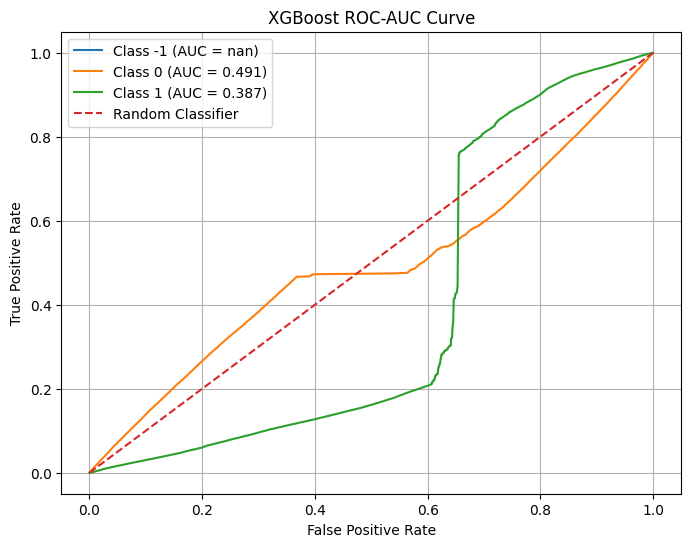

In [134]:
# Predictions
y_pred_xgb = model_xgb.predict(xtest)

# Probability predictions
y_prob_xgb = model_xgb.predict_proba(xtest)


# Accuracy
accuracy = accuracy_score(ytest, y_pred_xgb)

# Precision
precision = precision_score(ytest, y_pred_xgb, average="weighted", zero_division=0)

# Recall
recall = recall_score(ytest, y_pred_xgb, average="weighted", zero_division=0)

# F1 Score
f1 = f1_score(ytest, y_pred_xgb, average="weighted", zero_division=0)

# ROC-AUC
roc_auc = roc_auc_score(
    ytest,
    y_prob_xgb,
    multi_class="ovr",
    average="weighted"
)

print("Accuracy :", accuracy * 100)
print("Precision:", precision * 100)
print("Recall   :", recall * 100)
print("F1 Score :", f1 * 100)
print("ROC-AUC  :", roc_auc * 100)


# Classes
classes = [-1, 0, 1]

# Convert actual labels into binary form
ytest_bin = label_binarize(ytest, classes=classes)


# ROC-AUC Curve
plt.figure(figsize=(8, 6))

for i in range(len(classes)):

    fpr, tpr, thresholds = roc_curve(
        ytest_bin[:, i],
        y_prob_xgb[:, i]
    )

    auc_score = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"Class {classes[i]} (AUC = {auc_score:.3f})"
    )


# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC-AUC Curve")

plt.legend()
plt.grid(True)

plt.show()

<br></br>

# Performin AdaBoost

Training Score for AdaBoost : 49.505103738614295
Testing Score for AdaBoost  : 42.2209181441944
Accuracy Score for AdaBoost : 42.2209181441944
Classification Report
               precision    recall  f1-score   support

           0       0.42      1.00      0.59    192098
           1       0.00      0.00      0.00    113398
           2       0.00      0.00      0.00    149487

    accuracy                           0.42    454983
   macro avg       0.14      0.33      0.20    454983
weighted avg       0.18      0.42      0.25    454983



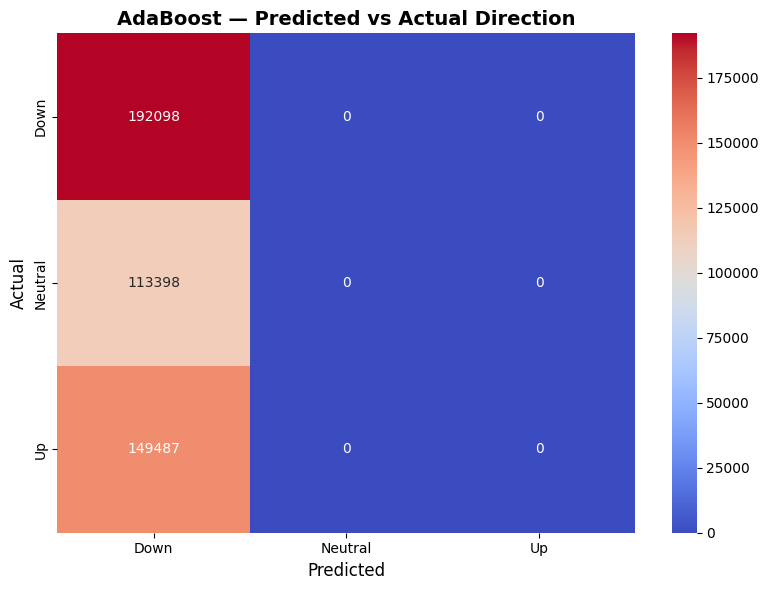

Accuracy : 42.2209181441944
Precision: 17.826059289387636
Recall   : 42.2209181441944
F1 Score : 25.06812573283238
ROC-AUC  : 61.58232658906926


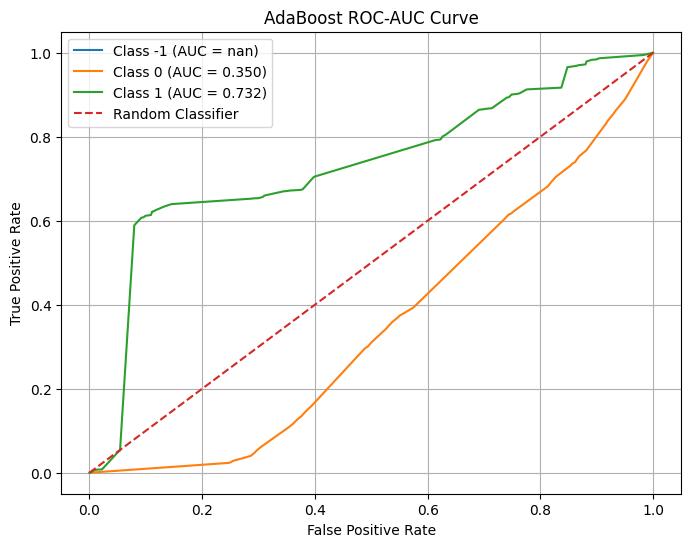

In [146]:
# Adaboost

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=3,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ),
    n_estimators=100,
    learning_rate=0.01,
    random_state=42
)

model_ada = ada.fit(xtrain, ytrain)

print("Training Score for AdaBoost :", model_ada.score(xtrain, ytrain) * 100)
print("Testing Score for AdaBoost  :", model_ada.score(xtest, ytest) * 100)


# Prediction
y_pred_ada = model_ada.predict(xtest)

# Accuracy Score
acc_ada = accuracy_score(ytest, y_pred_ada)
print("Accuracy Score for AdaBoost :", acc_ada * 100)

# Classification Report
class_rep_ada = classification_report(ytest, y_pred_ada)
print("Classification Report\n", class_rep_ada)

# Confusion Matrix
con_max_ada = confusion_matrix(ytest, y_pred_ada)

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    con_max_ada, annot=True, fmt='d', cmap="coolwarm",
    xticklabels=["Down", "Neutral", "Up"],
    yticklabels=["Down", "Neutral", "Up"]
)
plt.title("AdaBoost — Predicted vs Actual Direction", fontsize=14, fontweight='bold')
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.tight_layout()
plt.show()


# Probability predictions
y_prob_ada = model_ada.predict_proba(xtest)

# Accuracy
accuracy  = accuracy_score(ytest, y_pred_ada)
precision = precision_score(ytest, y_pred_ada, average="weighted", zero_division=0)
recall    = recall_score(ytest, y_pred_ada, average="weighted", zero_division=0)
f1        = f1_score(ytest, y_pred_ada, average="weighted", zero_division=0)
roc_auc   = roc_auc_score(ytest, y_prob_ada, multi_class="ovr", average="weighted")

print("Accuracy :", accuracy  * 100)
print("Precision:", precision * 100)
print("Recall   :", recall    * 100)
print("F1 Score :", f1        * 100)
print("ROC-AUC  :", roc_auc   * 100)


# Classes
classes = [-1, 0, 1]

# Binarize for ROC
ytest_bin = label_binarize(ytest, classes=classes)

# ROC-AUC Curve
plt.figure(figsize=(8, 6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(ytest_bin[:, i], y_prob_ada[:, i])
    auc_score   = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {classes[i]} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AdaBoost ROC-AUC Curve")
plt.legend()
plt.grid(True)
plt.show()

<br></br>

# Performin Gradient Boosting Classifier

In [75]:
gb = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=5,
    subsample=0.85,
    max_features="sqrt",
    random_state=42
)



model_gb = gb.fit(xtrain, ytrain)

# Training Score
print("Training Score for Gradient Boosting :",model_gb.score(xtrain, ytrain) * 100)

# Testing Score
print("Testing Score for Gradient Boosting :",model_gb.score(xtest, ytest) * 100)

Training Score for Gradient Boosting : 52.167361500354325
Testing Score for Gradient Boosting : 56.109568928948995


# Evaluation

Accuracy Score for XGBoost :  56.109568928948995
Classification Report               precision    recall  f1-score   support

          -1       0.50      0.85      0.63    192098
           0       0.88      0.58      0.70    113398
           1       0.46      0.18      0.26    149487

    accuracy                           0.56    454983
   macro avg       0.62      0.54      0.53    454983
weighted avg       0.59      0.56      0.53    454983



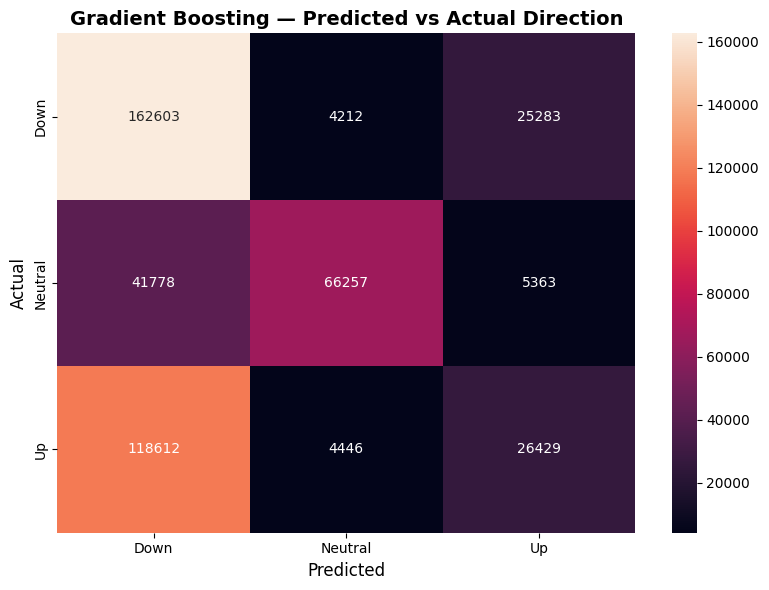

In [76]:
# Prediction
y_pred_gb = gb.predict(xtest)

# accuracy score 
acc_gb = accuracy_score(ytest,y_pred_gb)
print("Accuracy Score for XGBoost : ",acc_gb*100)


#Classification Report
class_rep_gb = classification_report(ytest,y_pred_gb)
print("Classification Report", class_rep_gb)

# Confusion Matrix
con_max_gb = confusion_matrix(ytest,y_pred_gb)

#heatmap 
plt.figure(figsize=(8, 6))
sns.heatmap(con_max_gb, annot=True, fmt='d', cmap="rocket",xticklabels=["Down", "Neutral", "Up"],yticklabels=["Down", "Neutral", "Up"])
plt.title("Gradient Boosting — Predicted vs Actual Direction", fontsize=14, fontweight='bold')
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.tight_layout()
plt.show()


Accuracy Score for XGBoost : 33.90214579445826
Classification Report
               precision    recall  f1-score   support

           0       0.48      0.14      0.22    192098
           1       0.10      0.00      0.00    113398
           2       0.32      0.85      0.46    149487

    accuracy                           0.34    454983
   macro avg       0.30      0.33      0.23    454983
weighted avg       0.34      0.34      0.25    454983



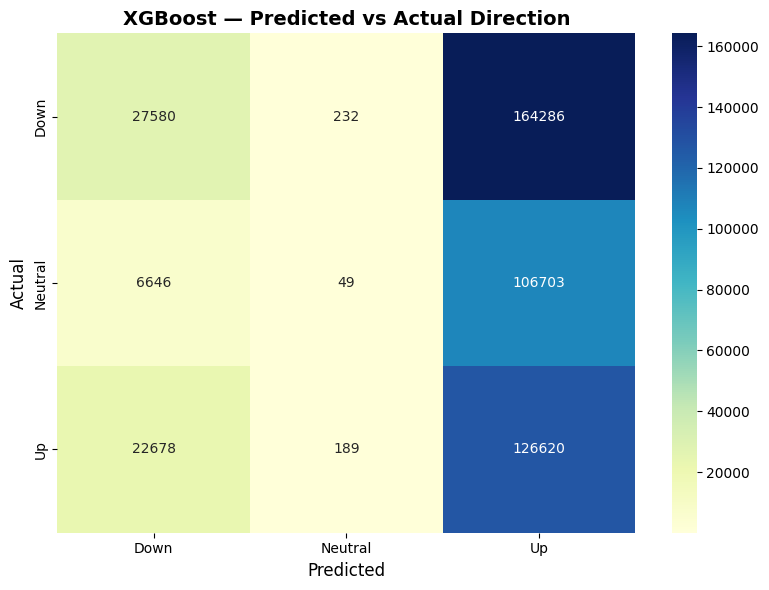

Accuracy : 33.90214579445826
Precision: 33.52483305876448
Recall   : 33.90214579445826
F1 Score : 24.5825829690254
ROC-AUC  : 49.75601936627842


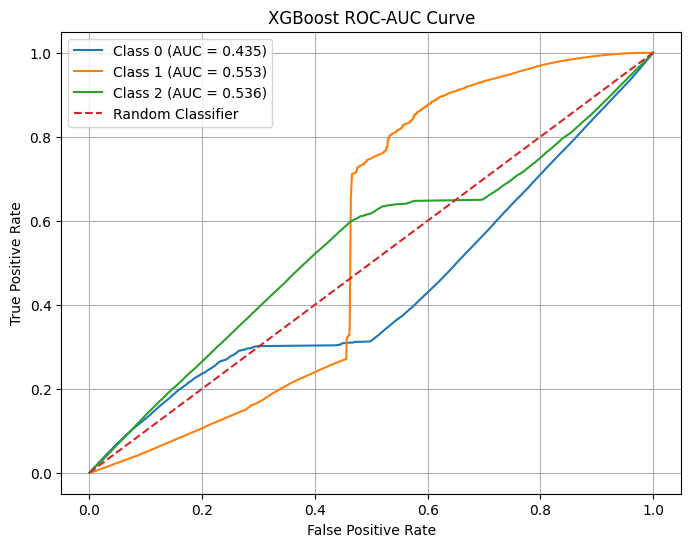

In [147]:
# Prediction
y_pred_xgb = xgb.predict(xtest)

# Accuracy Score
acc_xgb = accuracy_score(ytest_xgb, y_pred_xgb)
print("Accuracy Score for XGBoost :", acc_xgb * 100)

# Classification Report
class_rep_xgb = classification_report(ytest_xgb, y_pred_xgb)
print("Classification Report\n", class_rep_xgb)

# Confusion Matrix
con_max_xgb = confusion_matrix(ytest_xgb, y_pred_xgb)

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    con_max_xgb, annot=True, fmt='d', cmap="YlGnBu",
    xticklabels=["Down", "Neutral", "Up"],
    yticklabels=["Down", "Neutral", "Up"]
)
plt.title("XGBoost — Predicted vs Actual Direction", fontsize=14, fontweight='bold')
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.tight_layout()
plt.show()


# Probability predictions
y_prob_xgb = model_xgb.predict_proba(xtest)

# Accuracy
accuracy  = accuracy_score(ytest_xgb, y_pred_xgb)
precision = precision_score(ytest_xgb, y_pred_xgb, average="weighted", zero_division=0)
recall    = recall_score(ytest_xgb, y_pred_xgb, average="weighted", zero_division=0)
f1        = f1_score(ytest_xgb, y_pred_xgb, average="weighted", zero_division=0)
roc_auc   = roc_auc_score(ytest_xgb, y_prob_xgb, multi_class="ovr", average="weighted")

print("Accuracy :", accuracy  * 100)
print("Precision:", precision * 100)
print("Recall   :", recall    * 100)
print("F1 Score :", f1        * 100)
print("ROC-AUC  :", roc_auc   * 100)


# Classes — XGBoost e remapped, tai 0,1,2
classes = [0, 1, 2]

# Binarize for ROC
ytest_bin = label_binarize(ytest_xgb, classes=classes)

# ROC-AUC Curve
plt.figure(figsize=(8, 6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(ytest_bin[:, i], y_prob_xgb[:, i])
    auc_score   = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {classes[i]} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC-AUC Curve")
plt.legend()
plt.grid(True)
plt.show()

<br></br>

# Performing CatBoost Classifier

In [77]:
cat = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=5,
    random_strength=1,
    border_count=64,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    random_seed=42,
    verbose=100,
    thread_count=-1
)



model_cat = cat.fit(xtrain, ytrain)

# Training Score
print("Training Score for CatBoost Classifier :",model_cat.score(xtrain, ytrain) * 100)

# Testing Score
print("Testing Score forCatBoost Classifier :",model_cat.score(xtest, ytest) * 100)

0:	learn: 0.4966375	total: 391ms	remaining: 3m 15s
100:	learn: 0.5122831	total: 29.3s	remaining: 1m 55s
200:	learn: 0.5189053	total: 1m 4s	remaining: 1m 35s
300:	learn: 0.5221026	total: 1m 35s	remaining: 1m 3s
400:	learn: 0.5248145	total: 1m 56s	remaining: 28.8s
499:	learn: 0.5266220	total: 2m 22s	remaining: 0us
Training Score for CatBoost Classifier : 52.66220248459702
Testing Score forCatBoost Classifier : 56.19924260906451


Accuracy Score for XGBoost :  56.109568928948995
Classification Report               precision    recall  f1-score   support

          -1       0.50      0.85      0.63    192098
           0       0.88      0.58      0.70    113398
           1       0.46      0.18      0.26    149487

    accuracy                           0.56    454983
   macro avg       0.62      0.54      0.53    454983
weighted avg       0.59      0.56      0.53    454983



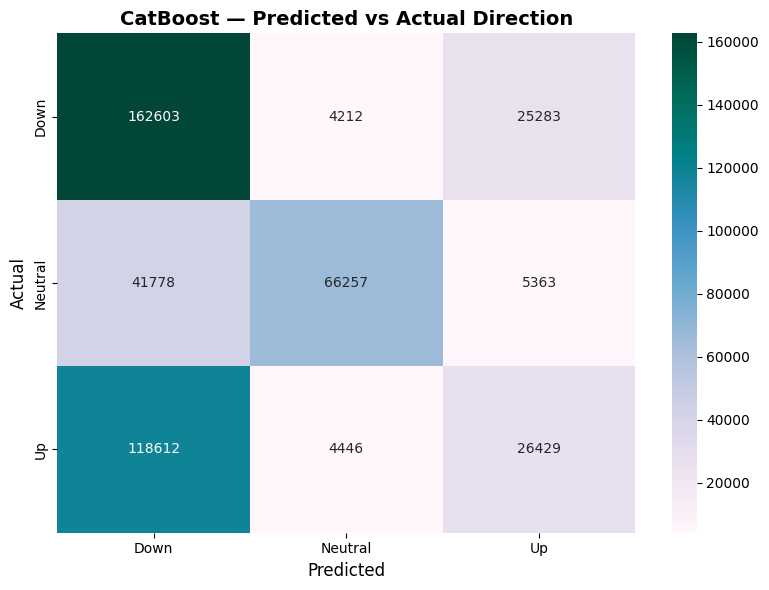

In [81]:
# Prediction
y_pred_cat = gb.predict(xtest)

# accuracy score 
acc_cat = accuracy_score(ytest,y_pred_cat)
print("Accuracy Score for XGBoost : ",acc_cat*100)


#Classification Report
class_rep_cat = classification_report(ytest,y_pred_cat)
print("Classification Report", class_rep_cat)

# Confusion Matrix
con_max_cat = confusion_matrix(ytest,y_pred_cat)

#heatmap 
plt.figure(figsize=(8, 6))
sns.heatmap(con_max_cat, annot=True, fmt='d', cmap="PuBuGn",xticklabels=["Down", "Neutral", "Up"],yticklabels=["Down", "Neutral", "Up"])
plt.title("CatBoost — Predicted vs Actual Direction", fontsize=14, fontweight='bold')
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.tight_layout()
plt.show()


Accuracy : 23.727040350958166
Precision: 6.874663489144677
Recall   : 23.727040350958166
F1 Score : 10.660544841456542
ROC-AUC  : 52.236390771294694


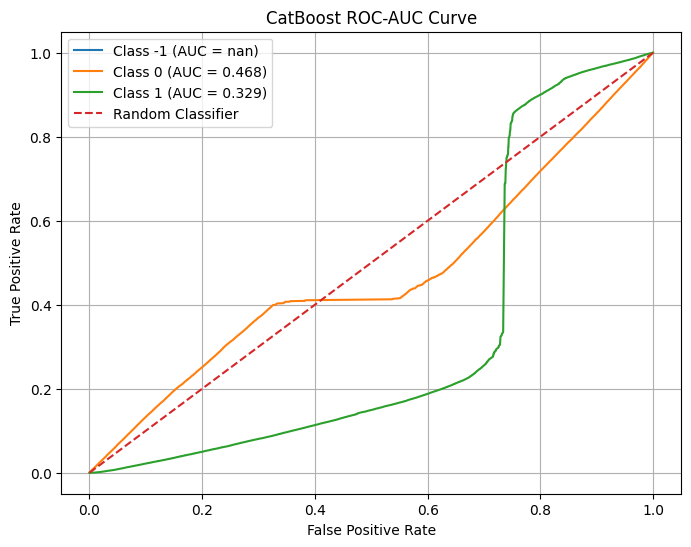

In [137]:
# Predictions
y_pred_cat = model_cat.predict(xtest)

# Probability predictions
y_prob_cat = model_cat.predict_proba(xtest)


# Accuracy
accuracy = accuracy_score(ytest, y_pred_cat)

# Precision
precision = precision_score(ytest, y_pred_cat, average="weighted", zero_division=0)

# Recall
recall = recall_score(ytest, y_pred_cat, average="weighted", zero_division=0)

# F1 Score
f1 = f1_score(ytest, y_pred_cat, average="weighted", zero_division=0)

# ROC-AUC
roc_auc = roc_auc_score(
    ytest,
    y_prob_cat,
    multi_class="ovr",
    average="weighted"
)

print("Accuracy :", accuracy * 100)
print("Precision:", precision * 100)
print("Recall   :", recall * 100)
print("F1 Score :", f1 * 100)
print("ROC-AUC  :", roc_auc * 100)


# Classes
classes = [-1, 0, 1]

# Convert actual labels into binary form
ytest_bin = label_binarize(ytest, classes=classes)


# ROC-AUC Curve
plt.figure(figsize=(8, 6))

for i in range(len(classes)):

    fpr, tpr, thresholds = roc_curve(
        ytest_bin[:, i],
        y_prob_cat[:, i]
    )

    auc_score = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"Class {classes[i]} (AUC = {auc_score:.3f})"
    )


# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CatBoost ROC-AUC Curve")

plt.legend()
plt.grid(True)

plt.show()

## Performing ANN

In [98]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

ytrain = le.fit_transform(ytrain)
ytest = le.transform(ytest)

print("Classes:", le.classes_)
print("Unique ytrain:", set(ytrain))

Classes: [0 1 2]
Unique ytrain: {np.int64(0), np.int64(1), np.int64(2)}


In [99]:
# Apply Scaling for X columns
scaler = StandardScaler()

xtrain = scaler.fit_transform(xtrain)
xtest = scaler.transform(xtest)

In [ ]:
# ANN Model

model = Sequential()


model.add(Dense(input_dim=xtrain.shape[1],kernel_initializer="he_normal",activation="relu",units=32))
model.add(Dropout(0.2))


model.add(Dense(kernel_initializer="he_normal",activation="relu",units=64))
model.add(Dropout(0.2))


model.add(Dense(kernel_initializer="he_normal",activation="relu",units=32))
model.add(Dropout(0.2))


model.add(Flatten())


model.add(Dense(kernel_initializer="he_normal",activation="relu",units=16))
model.add(Dropout(0.2))


model.add(Dense(kernel_initializer="he_normal",activation="softmax",units=len(np.unique(ytrain))))

model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [112]:
# Class Weight

classes = np.unique(ytrain)

weights = compute_class_weight(class_weight="balanced",classes=classes,y=ytrain)

class_weights = dict(zip(classes, weights))

print("Class Weights:", class_weights)


# Train

model.fit(xtrain,ytrain,epochs=500,batch_size=512,validation_split=0.1,class_weight=class_weights,verbose=1)


Class Weights: {np.int64(0): np.float64(0.6733312490229795), np.int64(1): np.float64(3.8134572819831782), np.int64(2): np.float64(0.798328205508396)}
Epoch 1/500
1590/1590 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3906 - loss: 0.9840 - val_accuracy: 0.3867 - val_loss: 1.0127
Epoch 2/500
1590/1590 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3899 - loss: 0.9836 - val_accuracy: 0.4098 - val_loss: 1.0110
Epoch 3/500
1590/1590 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.3895 - loss: 0.9838 - val_accuracy: 0.4242 - val_loss: 1.0133
Epoch 4/500
1590/1590 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3889 - loss: 0.9832 - val_accuracy: 0.4133 - val_loss: 1.0033
Epoch 5/500
1590/1590 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3895 - loss: 0.9838 - val_accuracy: 0.4198 - val_loss: 1.0066
Epoch 6/500
1590/1590 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3902 - loss: 0.9831 - val_accuracy: 0.4194 - val_loss: 1.0128
Epoch 7/500
1590/1590 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accurac

In [113]:
# Training Score
train_score = model.evaluate(xtrain,ytrain,verbose=0)[1]

print("Training Score for ANN :", train_score * 100)


# Testing Score


test_score = model.evaluate(xtest,ytest,verbose=0)[1]

print("Testing Score for ANN :", test_score * 100)

Training Score for ANN : 39.130690693855286
Testing Score for ANN : 52.70856022834778


# Evaluaion

14219/14219 ━━━━━━━━━━━━━━━━━━━━ 10s 665us/step
Accuracy Score for ANN :  52.70856273750888
Classification Report
              precision    recall  f1-score   support

           0       0.55      0.59      0.57    192098
           1       0.54      0.85      0.66    113398
           2       0.42      0.21      0.28    149487

    accuracy                           0.53    454983
   macro avg       0.51      0.55      0.50    454983
weighted avg       0.51      0.53      0.50    454983



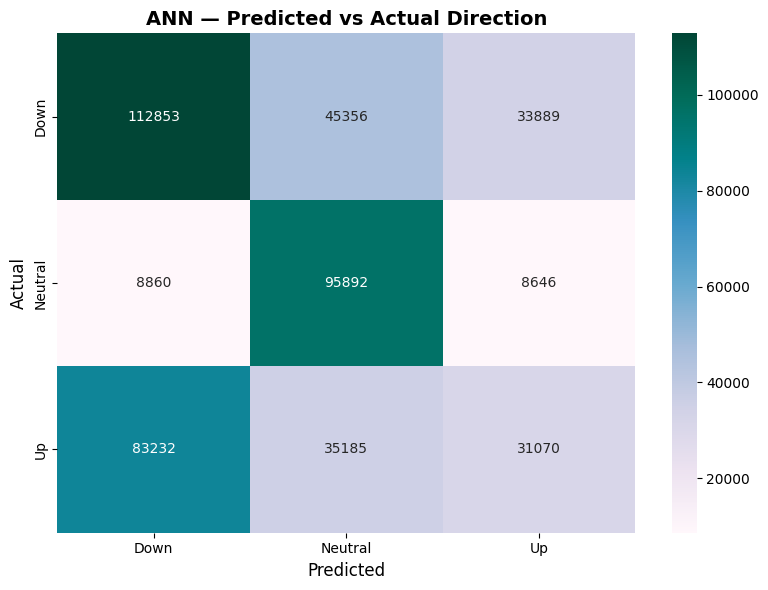

In [114]:
# Prediction
y_pred_ann = model.predict(xtest)

# Convert probabilities to class labels
y_pred_ann = np.argmax(y_pred_ann, axis=1)


# Accuracy Score
acc_ann = accuracy_score(ytest, y_pred_ann)

print("Accuracy Score for ANN : ", acc_ann * 100)


# Classification Report
class_rep_ann = classification_report(ytest, y_pred_ann)

print("Classification Report")
print(class_rep_ann)


# Confusion Matrix
con_max_ann = confusion_matrix(ytest, y_pred_ann)


# Heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    con_max_ann,
    annot=True,
    fmt='d',
    cmap="PuBuGn",
    xticklabels=["Down", "Neutral", "Up"],
    yticklabels=["Down", "Neutral", "Up"]
)

plt.title(
    "ANN — Predicted vs Actual Direction",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)

plt.tight_layout()
plt.show()

14219/14219 ━━━━━━━━━━━━━━━━━━━━ 11s 796us/step
Accuracy : 11.869014886270476
Precision: 13.781462803521356
Recall   : 11.869014886270476
F1 Score : 12.697120753254223
ROC-AUC  : 70.98022156028502


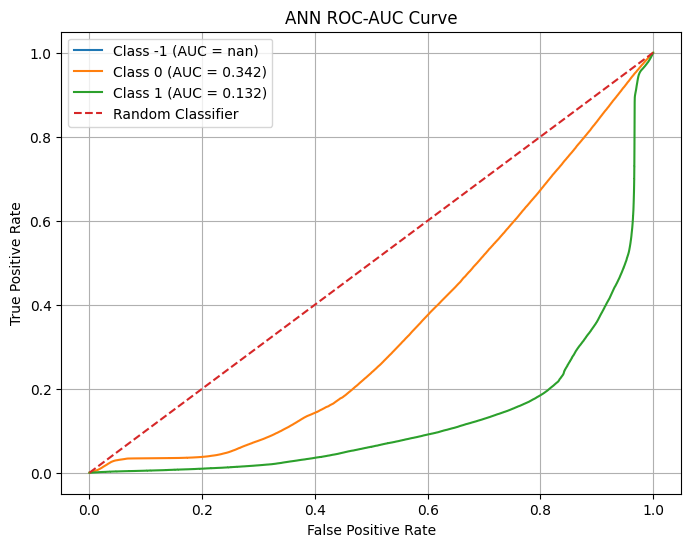

In [ ]:
# Probability predictions
y_prob_ann = model.predict(xtest)

# Convert probabilities into predicted class index
y_pred_ann = np.argmax(y_prob_ann, axis=1)

# Convert class index back to original labels
class_labels = [-1, 0, 1]
y_pred_ann = np.array(class_labels)[y_pred_ann]


# Accuracy
accuracy = accuracy_score(ytest, y_pred_ann)

# Precision
precision = precision_score(ytest,y_pred_ann,average="weighted",zero_division=0)
# Recall
recall = recall_score(ytest,y_pred_ann,average="weighted",zero_division=0)

# F1 Score
f1 = f1_score(ytest,y_pred_ann,average="weighted",zero_division=0)

# ROC-AUC
roc_auc = roc_auc_score(ytest,y_prob_ann,multi_class="ovr",average="weighted")


# Print evaluation results
print("Accuracy :", accuracy * 100)
print("Precision:", precision * 100)
print("Recall   :", recall * 100)
print("F1 Score :", f1 * 100)
print("ROC-AUC  :", roc_auc * 100)


# Classes
classes = [-1, 0, 1]

# Convert actual labels into binary form
ytest_bin = label_binarize(ytest,classes=classes)


# ROC-AUC Curve
plt.figure(figsize=(8, 6))

for i in range(len(classes)):

    # Calculate False Positive Rate and True Positive Rate
    fpr, tpr, thresholds = roc_curve(ytest_bin[:, i],y_prob_ann[:, i])

    # Calculate AUC
    auc_score = auc(fpr, tpr)

    # Plot ROC curve
    plt.plot(fpr,tpr,label=f"Class {classes[i]} (AUC = {auc_score:.3f})")


# Random classifier reference line
plt.plot([0, 1],[0, 1],linestyle="--",label="Random Classifier")


# Graph labels
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ANN ROC-AUC Curve")

plt.legend()
plt.grid(True)

plt.show()